# FreshRetailNet-50K: Full-Data GPU Framework Using the Method from the Uploaded LUR Notebook

This notebook follows the same modeling sequence used in the uploaded code:

1. **Initial Bayesian hyperparameter tuning** with Optuna.
2. Freeze those initial hyperparameters.
3. Perform **forward feature selection one feature at a time** with `GridSearchCV`.
4. Within each feature-selection step, every remaining feature is evaluated with a singleton parameter grid and `scoring="neg_mean_squared_error"`.
5. After one feature is accepted, **recreate the seven-day evaluation-like data chunks and rebuild the CV folds**.
6. Continue until the best remaining feature does not improve the previous accepted mean negative MSE.
7. Perform **one final Bayesian hyperparameter tuning** using all selected features.
8. In the final Bayesian study, tune `reg_alpha` (L1) and `reg_lambda` (L2) jointly with learning rate, number of trees, depth, and subsampling.
9. Train one final GPU XGBoost model on the complete development period.
10. Evaluate once on the untouched official seven-day evaluation period and compare WAPE/WPE with the published FreshRetailNet-50K results.

The full-data configuration uses all 50,000 store-product series. No hyperparameter retuning occurs between feature-selection steps.


## Revision: automatic eight-chunk cap and corrected CV eligibility

The 90-day training period supports eight non-overlapping seven-day development origins after reserving 28 days for lag construction. This notebook automatically uses the available count and bases CV eligibility on earlier materialized origin chunks.


> **Revision:** the temporal-CV history window is fixed at **28 days** (matching `max_lag=28`). The dataclass default and active configuration now agree, and a diagnostic check verifies that at least four eligible temporal origins exist before CV begins.


## Dataset and methodological references

### FreshRetailNet-50K

- Dataset: [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)
- Official baseline repository: [Dingdong-Inc/frn-50k-baseline](https://github.com/Dingdong-Inc/frn-50k-baseline)
- Paper: [FreshRetailNet-50K](https://arxiv.org/abs/2505.16319)

The released dataset contains 50,000 store-product series, 4.5 million training rows, and 350,000 official evaluation rows. The official forecasting task predicts seven daily values and evaluates forecasting during non-stockout operational periods using WAPE and WPE.

### Paper-inspired development logic

The attached UFP paper aligns feature selection and hyperparameter optimization with a structured cross-validation strategy. This notebook transfers that principle to a retail forecasting setting using rolling temporal folds and an untouched official evaluation period.


## Leakage control and exact model-selection rules

- The official evaluation period is never used for initial tuning, feature selection, or final tuning.
- Every CV validation fold is a **complete seven-day forecast chunk**, matching the official evaluation structure: one forecast origin, all series, and horizons 1 through 7.
- Each fold trains only on target dates that occur on or before the fold's forecast origin.
- Initial Bayesian tuning uses one fixed set of chunks for all Optuna trials.
- The initially tuned hyperparameters are frozen during all forward-selection steps.
- Feature selection uses `GridSearchCV` with a singleton parameter grid, matching the uploaded notebook.
- Within one selection step, all candidate features use exactly the same chunks and CV folds.
- After an accepted feature, the chunk origins and CV folds are regenerated using a new reset seed.
- The default stopping rule matches the uploaded notebook: accept the best candidate only when its mean negative MSE exceeds the best score from the previously accepted step.
- A same-reset baseline score is also logged for diagnosis, but it does not control acceptance unless the configuration is changed.
- Final Bayesian tuning is run once using all selected features; L1 and L2 are included in that joint search.
- Every XGBoost fit uses `tree_method="hist"` and `device="cuda"`.
- WAPE and WPE are used only for official evaluation and comparison with the published paper.


## Full-data runtime requirements

This notebook defaults to the **complete dataset**:

- `series_limit=None`
- 50,000 store-product series
- no fold-level row subsampling
- rolling temporal CV
- GPU XGBoost for initial tuning, every feature candidate, final tuning, and final fitting

Recommended runtime:

- Google Colab High-RAM with an NVIDIA A100/L4, or a comparable CUDA machine
- at least 25–40 GB system RAM
- substantial runtime, because individual forward selection can fit many models

The workflow saves checkpoints after tuning decisions and after every accepted feature so an interrupted run can be inspected and resumed manually.


## 1. Install dependencies


In [ ]:
%pip install -q "datasets>=3.0" "xgboost>=2.1" "scikit-learn>=1.4" \
    "pandas>=2.0" "pyarrow>=15" "tqdm>=4.66" "joblib>=1.3" \
    "optuna>=4.0" "shap>=0.45" "matplotlib>=3.8"


## 2. Imports, constants, dataset loader, configuration, and artifact helpers

The loader first reads only store and product identifiers to sample complete series. It then materializes only the daily columns needed by this project, avoiding the two list-valued hourly columns unless they are explicitly required later.


In [ ]:
import gc
import hashlib
import json
import math
import os
import random
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, cross_val_score
from tqdm.auto import tqdm
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler


ID_COLUMNS = [
    "city_id",
    "store_id",
    "management_group_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "product_id",
]

KNOWN_FUTURE_COLUMNS = [
    "discount",
    "holiday_flag",
    "activity_flag",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level",
]


DAILY_DATA_COLUMNS = ID_COLUMNS + [
    "dt",
    "sale_amount",
    "stock_hour6_22_cnt",
    "discount",
    "holiday_flag",
    "activity_flag",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level",
]


def load_freshretail_from_huggingface(
    series_limit: int | None = None,
    seed: int = 42,
    dataset_name: str = "Dingdong-Inc/FreshRetailNet-50K",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load only the daily columns required by the forecasting workflow.

    In the requested full-data mode (`series_limit=None`), the function avoids
    the expensive identifier-membership pass and directly materializes all
    4.5M training rows and all 350K official evaluation rows.
    """
    try:
        from datasets import load_dataset
    except ImportError as error:
        raise ImportError(
            "Install the 'datasets' package before loading FreshRetailNet-50K"
        ) from error

    dataset = load_dataset(dataset_name)
    train_ds = dataset["train"]
    eval_ds = dataset["eval"]

    if series_limit is None:
        train_frame = train_ds.select_columns(DAILY_DATA_COLUMNS).to_pandas()
        eval_frame = eval_ds.select_columns(DAILY_DATA_COLUMNS).to_pandas()
        selected_series = (
            train_frame[["store_id", "product_id"]]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        return train_frame, eval_frame, selected_series

    # Optional subset path retained only for debugging.
    train_ids = train_ds.select_columns(["store_id", "product_id"]).to_pandas()
    unique_series = train_ids.drop_duplicates().reset_index(drop=True)
    selected_series = unique_series.sample(
        n=min(series_limit, len(unique_series)),
        random_state=seed,
    ).reset_index(drop=True)
    selected_keys = set(
        zip(
            selected_series["store_id"].astype(int),
            selected_series["product_id"].astype(int),
        )
    )

    def selected_positions(identifier_frame: pd.DataFrame) -> np.ndarray:
        keys = zip(
            identifier_frame["store_id"].astype(int),
            identifier_frame["product_id"].astype(int),
        )
        mask = np.fromiter(
            (key in selected_keys for key in keys),
            dtype=bool,
            count=len(identifier_frame),
        )
        return np.flatnonzero(mask)

    train_positions = selected_positions(train_ids)
    del train_ids
    gc.collect()
    eval_ids = eval_ds.select_columns(["store_id", "product_id"]).to_pandas()
    eval_positions = selected_positions(eval_ids)
    del eval_ids
    gc.collect()

    train_frame = (
        train_ds.select(train_positions)
        .select_columns(DAILY_DATA_COLUMNS)
        .to_pandas()
    )
    eval_frame = (
        eval_ds.select(eval_positions)
        .select_columns(DAILY_DATA_COLUMNS)
        .to_pandas()
    )
    return train_frame, eval_frame, selected_series


@dataclass
class ExperimentConfig:
    random_seed: int = 42
    run_mode: str = "full"    #    "full"
    series_limit: int | None = None
    forecast_horizon: int = 7
    max_lag: int = 28

    # Memory-safe supervised construction: keep all 50,000 series, but
    # materialize only evaluation-like forecast-origin chunks.
    development_origin_chunks: int = 8
    development_origin_stride_days: int = 7

    # Evaluation-like temporal CV chunks.
    cv_mode: str = "evaluation_like_temporal_chunks"
    cv_n_splits: int = 4
    cv_chunk_days: int = 7
    cv_candidate_origins: int = 8
    cv_min_train_days: int = 28
    cv_min_train_origin_chunks: int = 2
    cv_min_chunk_separation_days: int = 7
    dynamic_chunk_sampling: bool = True

    # Full data: no row sampling inside folds.
    max_train_rows_per_fold: int | None = None
    max_validation_rows_per_fold: int | None = None

    # Forward-selection rule used in the uploaded notebook.
    min_feature_improvement: float = 0.0
    max_feature_steps: int | None = None
    feature_selection_acceptance_rule: str = "uploaded_notebook"
    # Valid values:
    # - "uploaded_notebook": compare with the best score from the prior accepted step.
    # - "same_reset_baseline": compare with the current selected set on the same fresh chunks.

    # Bayesian optimization.
    initial_optuna_trials: int = 30
    final_optuna_trials: int = 300
    optuna_timeout_seconds: int | None = None

    # GPU is required for the requested full-data workflow.
    xgb_device: str = "cuda"
    require_gpu: bool = True
    xgb_cpu_threads: int = 4
    cv_n_jobs: int = 1
    grid_search_n_jobs: int = 1
    early_stopping_rounds: int = 50

    output_dir: str = "artifacts/freshretail_full_gpu_uploaded_code_method"
    use_stockout_adjusted_proxy: bool = False
    verbose: bool = True

    def validate(self) -> None:
        if self.forecast_horizon < 1:
            raise ValueError("forecast_horizon must be >= 1")
        if self.cv_chunk_days != self.forecast_horizon:
            raise ValueError(
                "cv_chunk_days must equal forecast_horizon so each CV chunk "
                "matches the official evaluation structure"
            )
        if self.cv_n_splits < 2:
            raise ValueError("cv_n_splits must be >= 2")
        if self.cv_min_train_days < self.max_lag:
            raise ValueError(
                "cv_min_train_days must be at least max_lag so each fold has "
                "enough historical coverage for the longest lag feature"
            )
        minimum_required_chunks = (
            self.cv_n_splits + self.cv_min_train_origin_chunks
        )
        if self.development_origin_chunks < minimum_required_chunks:
            raise ValueError(
                "development_origin_chunks must be at least cv_n_splits + "
                "cv_min_train_origin_chunks so every validation fold has earlier "
                "materialized training chunks"
            )
        if self.cv_candidate_origins < self.cv_n_splits:
            raise ValueError(
                "cv_candidate_origins must be at least cv_n_splits"
            )
        if self.cv_min_train_origin_chunks < 1:
            raise ValueError(
                "cv_min_train_origin_chunks must be at least 1"
            )
        if self.development_origin_stride_days < self.forecast_horizon:
            raise ValueError(
                "development_origin_stride_days must be at least the forecast horizon "
                "to keep materialized origin chunks non-overlapping"
            )
        if self.cv_min_chunk_separation_days < self.cv_chunk_days:
            raise ValueError(
                "cv_min_chunk_separation_days must be at least cv_chunk_days "
                "to prevent validation chunks from overlapping"
            )
        if self.series_limit is not None:
            raise ValueError("Full-data mode requires series_limit=None")
        if self.xgb_device != "cuda" and self.require_gpu:
            raise ValueError("Full-data mode requires xgb_device='cuda'")
        if self.initial_optuna_trials < 1 or self.final_optuna_trials < 1:
            raise ValueError("Optuna trial counts must be positive")
        if self.feature_selection_acceptance_rule not in {
            "uploaded_notebook",
            "same_reset_baseline",
        }:
            raise ValueError(
                "feature_selection_acceptance_rule must be "
                "'uploaded_notebook' or 'same_reset_baseline'"
            )
        if self.cv_n_jobs != 1 or self.grid_search_n_jobs != 1:
            raise ValueError(
                "A single GPU should use cv_n_jobs=1 and grid_search_n_jobs=1 "
                "to avoid launching competing CUDA fits."
            )


@dataclass
class CombinedResult:
    initial_params: dict[str, Any]
    selected_features: list[str]
    final_params: dict[str, Any]
    initial_tuning_log: pd.DataFrame
    feature_selection_log: pd.DataFrame
    final_tuning_log: pd.DataFrame
    cv_reset_log: pd.DataFrame


class ArtifactStore:
    """Small checkpoint/artifact helper."""

    def __init__(self, root: str | Path):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)

    def save_json(self, name: str, payload: Mapping[str, Any] | Sequence[Any]) -> Path:
        path = self.root / name
        path.parent.mkdir(parents=True, exist_ok=True)
        with path.open("w", encoding="utf-8") as file:
            json.dump(payload, file, indent=2, default=_json_default)
        return path

    def save_frame(self, name: str, frame: pd.DataFrame) -> Path:
        path = self.root / name
        path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_csv(path, index=False)
        return path


def _json_default(value: Any) -> Any:
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (pd.Timestamp, np.datetime64)):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"Object of type {type(value).__name__} is not JSON serializable")


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def verify_cuda_xgboost(require_gpu: bool = True) -> None:
    """Fail early when the requested CUDA XGBoost runtime is unavailable."""
    probe_x = np.array([[0.0], [1.0], [2.0], [3.0]], dtype=np.float32)
    probe_y = np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32)
    try:
        probe = xgb.XGBRegressor(
            n_estimators=2,
            max_depth=2,
            tree_method="hist",
            device="cuda",
            objective="reg:squarederror",
            verbosity=0,
        )
        probe.fit(probe_x, probe_y, verbose=False)
        del probe
        gc.collect()
        print("CUDA XGBoost check passed.")
    except Exception as error:
        message = (
            "CUDA XGBoost is unavailable. In Colab choose Runtime > Change runtime type "
            "> Hardware accelerator > GPU, then rerun the notebook."
        )
        if require_gpu:
            raise RuntimeError(message) from error
        print("WARNING:", message)


def release_model_memory(*objects: Any) -> None:
    """Release Python and optional CuPy memory between repeated GPU fits."""
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    try:
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass


def make_series_id(frame: pd.DataFrame) -> pd.Series:
    return frame["store_id"].astype(str) + "_" + frame["product_id"].astype(str)


def sample_complete_series(
    frame: pd.DataFrame,
    n_series: int | None,
    seed: int,
    series_column: str = "series_id",
) -> pd.DataFrame:
    """Select complete time series instead of sampling individual rows."""
    if n_series is None:
        return frame.copy()
    unique_series = frame[series_column].drop_duplicates().to_numpy()
    if n_series >= len(unique_series):
        return frame.copy()
    rng = np.random.default_rng(seed)
    selected = rng.choice(unique_series, size=n_series, replace=False)
    return frame[frame[series_column].isin(selected)].copy()



## 3. Configure the complete experiment

The default configuration intentionally has no smoke/development sampling. Change only the search breadth—not the dataset size—when reducing runtime.


In [ ]:
RUN_MODE = "full"

config = ExperimentConfig(
    random_seed=42,
    run_mode=RUN_MODE,
    series_limit=None,
    forecast_horizon=7,

    # Keep every store-product series, but materialize up to 8 non-overlapping
    # seven-day forecast-origin chunks instead of every daily origin.
    development_origin_chunks=8,
    development_origin_stride_days=7,

    # Each validation fold is one complete seven-day forecast chunk.
    cv_mode="evaluation_like_temporal_chunks",
    cv_n_splits=4,
    cv_chunk_days=7,
    cv_candidate_origins=8,
    cv_min_train_days=28,
    cv_min_train_origin_chunks=2,
    cv_min_chunk_separation_days=7,
    dynamic_chunk_sampling=True,

    # Full dataset in every fold: 50,000 complete store-product series.
    max_train_rows_per_fold=None,
    max_validation_rows_per_fold=None,

    # Match the uploaded notebook's forward-selection stopping rule.
    min_feature_improvement=0.0,
    max_feature_steps=None,
    feature_selection_acceptance_rule="uploaded_notebook",

    # Same Optuna sequence as the uploaded code:
    # 30 initial trials, then 300 final trials with L1 and L2 included.
    initial_optuna_trials=30,
    final_optuna_trials=300,
    optuna_timeout_seconds=None,

    # Every XGBoost fit runs on one CUDA GPU.
    xgb_device="cuda",
    require_gpu=True,
    xgb_cpu_threads=4,
    cv_n_jobs=1,
    grid_search_n_jobs=1,
    early_stopping_rounds=50,

    use_stockout_adjusted_proxy=False,
    output_dir="artifacts/freshretail_full_gpu_uploaded_code_method",
    verbose=True,
)

config.validate()
seed_everything(config.random_seed)
verify_cuda_xgboost(config.require_gpu)
artifact_store = ArtifactStore(config.output_dir)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(config)


CUDA XGBoost check passed.
ExperimentConfig(random_seed=42, run_mode='full', series_limit=None, forecast_horizon=7, max_lag=28, development_origin_chunks=8, development_origin_stride_days=7, cv_mode='evaluation_like_temporal_chunks', cv_n_splits=4, cv_chunk_days=7, cv_candidate_origins=8, cv_min_train_days=28, cv_min_train_origin_chunks=2, cv_min_chunk_separation_days=7, dynamic_chunk_sampling=True, max_train_rows_per_fold=None, max_validation_rows_per_fold=None, min_feature_improvement=0.0, max_feature_steps=None, feature_selection_acceptance_rule='uploaded_notebook', initial_optuna_trials=30, final_optuna_trials=300, optuna_timeout_seconds=None, xgb_device='cuda', require_gpu=True, xgb_cpu_threads=4, cv_n_jobs=1, grid_search_n_jobs=1, early_stopping_rounds=50, output_dir='artifacts/freshretail_full_gpu_uploaded_code_method', use_stockout_adjusted_proxy=False, verbose=True)


## 4. Download and load all FreshRetailNet-50K series

The complete official splits are loaded:

- training: 4,500,000 daily rows
- evaluation: 350,000 daily rows
- 50,000 complete store-product series

No series sampling is applied.


In [ ]:

train_raw, eval_raw, selected_series = load_freshretail_from_huggingface(
    series_limit=config.series_limit,
    seed=config.random_seed,
)

print("Selected series:", len(selected_series))
print("Training rows:", f"{len(train_raw):,}")
print("Evaluation rows:", f"{len(eval_raw):,}")
display(train_raw.head())


Selected series: 50000
Training rows: 4,500,000
Evaluation rows: 350,000


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.1,0,1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.1,1,1.0,0,0,3.0190,15.08,76.56,1.71
2,0,0,0,5,6,65,38,2024-03-30,0.0,0,1.0,1,0,2.0942,15.91,76.47,1.73
3,0,0,0,5,6,65,38,2024-03-31,0.1,11,1.0,1,0,1.5618,16.13,77.40,1.76
4,0,0,0,5,6,65,38,2024-04-01,0.2,8,1.0,0,0,3.5386,15.37,78.26,1.25



## 5. Prepare the daily panel

This stage:

- combines the official train and evaluation splits only for chronological feature construction;
- keeps a `dataset_split` label;
- creates a unique `series_id = store_id + product_id`;
- records the last training date;
- preserves the official evaluation targets for final scoring only.

Combining the tables does not create leakage because later filtering prevents evaluation labels from entering development folds.


In [ ]:
def optimize_panel_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    for column in ID_COLUMNS:
        if column in result:
            result[column] = pd.to_numeric(result[column], downcast="integer")
    integer_columns = ["stock_hour6_22_cnt", "holiday_flag", "activity_flag"]
    for column in integer_columns:
        if column in result:
            result[column] = pd.to_numeric(result[column], downcast="integer")
    float_columns = [
        "sale_amount",
        "discount",
        "precpt",
        "avg_temperature",
        "avg_humidity",
        "avg_wind_level",
    ]
    for column in float_columns:
        if column in result:
            result[column] = pd.to_numeric(result[column], downcast="float")
    return result


def prepare_daily_panel(
    train_frame: pd.DataFrame,
    eval_frame: pd.DataFrame | None = None,
    series_limit: int | None = None,
    seed: int = 42,
) -> tuple[pd.DataFrame, pd.Timestamp, pd.Timestamp | None]:
    """Create a clean daily panel and retain full series across train/eval."""
    required = set(ID_COLUMNS + [
        "dt",
        "sale_amount",
        "stock_hour6_22_cnt",
        "discount",
        "holiday_flag",
        "activity_flag",
        "precpt",
        "avg_temperature",
        "avg_humidity",
        "avg_wind_level",
    ])
    missing = required.difference(train_frame.columns)
    if missing:
        raise KeyError(f"Training data is missing required columns: {sorted(missing)}")

    train = train_frame[list(required)].copy()
    train["dataset_split"] = "train"
    frames = [train]

    eval_start = None
    if eval_frame is not None:
        missing_eval = required.difference(eval_frame.columns)
        if missing_eval:
            raise KeyError(f"Evaluation data is missing required columns: {sorted(missing_eval)}")
        evaluation = eval_frame[list(required)].copy()
        evaluation["dataset_split"] = "eval"
        frames.append(evaluation)

    panel = pd.concat(frames, ignore_index=True)
    panel["dt"] = pd.to_datetime(panel["dt"], errors="raise")
    panel["series_id"] = make_series_id(panel)
    panel = sample_complete_series(panel, series_limit, seed)
    panel = panel.sort_values(["series_id", "dt"]).reset_index(drop=True)
    panel = optimize_panel_dtypes(panel)

    train_end = panel.loc[panel["dataset_split"] == "train", "dt"].max()
    if (panel["dataset_split"] == "eval").any():
        eval_start = panel.loc[panel["dataset_split"] == "eval", "dt"].min()
    return panel, pd.Timestamp(train_end), None if eval_start is None else pd.Timestamp(eval_start)


def add_causal_stockout_adjusted_proxy(
    panel: pd.DataFrame,
    target_column: str = "sale_amount",
    output_column: str = "demand_proxy",
) -> pd.DataFrame:
    """Create a transparent causal demand proxy for stockout days.

    This is NOT the official deep latent-demand recovery method. It uses only
    previously observed non-stockout sales from the same series and weekday.
    """
    result = panel.copy()
    result["day_of_week"] = result["dt"].dt.dayofweek.astype("int8")
    result["is_stockout_day"] = (result["stock_hour6_22_cnt"] > 0).astype("int8")
    uncensored = result[target_column].where(result["is_stockout_day"] == 0)

    temp = result[["series_id", "day_of_week"]].copy()
    temp["uncensored"] = uncensored
    proxy = (
        temp.groupby(["series_id", "day_of_week"], observed=True)["uncensored"]
        .transform(lambda series: series.shift(1).rolling(4, min_periods=1).median())
    )
    fallback = (
        result.groupby("series_id", observed=True)[target_column]
        .transform(lambda series: series.shift(1).rolling(7, min_periods=1).median())
    )
    proxy = proxy.fillna(fallback).fillna(result[target_column])
    result[output_column] = np.where(
        result["is_stockout_day"].eq(1),
        np.maximum(result[target_column], proxy),
        result[target_column],
    ).astype("float32")
    return result



In [ ]:
panel, train_end, eval_start = prepare_daily_panel(
    train_frame=train_raw,
    eval_frame=eval_raw,
    series_limit=None,  # sampling was already performed by the loader
    seed=config.random_seed,
)

if config.use_stockout_adjusted_proxy:
    panel = add_causal_stockout_adjusted_proxy(
        panel,
        target_column="sale_amount",
        output_column="demand_proxy",
    )
    TARGET_COLUMN = "demand_proxy"
else:
    TARGET_COLUMN = "sale_amount"

print("Training end:", train_end.date())
print("Evaluation start:", eval_start.date())
print("Model target:", TARGET_COLUMN)
display(panel.head())


Training end: 2024-06-25
Evaluation start: 2024-06-26
Model target: sale_amount


,discount,second_category_id,precpt,avg_temperature,holiday_flag,product_id,stock_hour6_22_cnt,management_group_id,avg_humidity,third_category_id,avg_wind_level,dt,first_category_id,city_id,sale_amount,activity_flag,store_id,dataset_split,series_id
0,1.000,50,1.6999,15.480000,0,104,1,6,73.540001,2,1.97,2024-03-28,20,0,0.5,0,0,train,0_104
1,0.976,50,3.0190,15.080000,0,104,0,6,76.559998,2,1.71,2024-03-29,20,0,0.9,0,0,train,0_104
2,0.928,50,2.0942,15.910000,1,104,1,6,76.470001,2,1.73,2024-03-30,20,0,0.7,0,0,train,0_104
3,1.000,50,1.5618,16.129999,1,104,7,6,77.400002,2,1.76,2024-03-31,20,0,0.9,0,0,train,0_104
4,0.976,50,3.5386,15.370000,0,104,6,6,78.260002,2,1.25,2024-04-01,20,0,0.8,0,0,train,0_104


### Panel summary and integrity checks

In [ ]:
panel_summary = pd.DataFrame({
    "metric": [
        "rows",
        "series",
        "stores",
        "cities",
        "products",
        "start_date",
        "end_date",
        "stockout_day_share",
    ],
    "value": [
        len(panel),
        panel["series_id"].nunique(),
        panel["store_id"].nunique(),
        panel["city_id"].nunique(),
        panel["product_id"].nunique(),
        panel["dt"].min(),
        panel["dt"].max(),
        float((panel["stock_hour6_22_cnt"] > 0).mean()),
    ],
})
display(panel_summary)

duplicates = panel.duplicated(["series_id", "dt"]).sum()
missing_dates_per_series = (
    panel.groupby("series_id", observed=True)["dt"]
    .nunique()
    .describe()
)

print("Duplicate series-date rows:", duplicates)
print("\nDates per series:")
display(missing_dates_per_series)

assert duplicates == 0, "Duplicate series-date rows must be resolved before modeling."
assert train_end < eval_start, "Training and evaluation periods overlap."

,metric,value
0,rows,4850000
1,series,50000
2,stores,898
3,cities,18
4,products,865
5,start_date,2024-03-28 00:00:00
6,end_date,2024-07-02 00:00:00
7,stockout_day_share,0.440298


Duplicate series-date rows: 0

Dates per series:


,dt
count,50000.0
mean,97.0
std,0.0
min,97.0
25%,97.0
50%,97.0
75%,97.0
max,97.0



## 6. Create causal origin-date features

All target-derived features are calculated before the multi-horizon target is created.

Feature families include:

- current and lagged demand;
- rolling level and variability;
- demand trend;
- historical stockout burden;
- promotion changes;
- origin-date seasonality.

XGBoost trees do not require feature scaling, so no `MinMaxScaler` is used.


In [ ]:
def _group_rolling(
    values: pd.Series,
    groups: pd.Series,
    window: int,
    statistic: str,
    min_periods: int,
) -> pd.Series:
    roller = values.groupby(groups, observed=True).rolling(window, min_periods=min_periods)
    if statistic == "mean":
        result = roller.mean()
    elif statistic == "std":
        result = roller.std()
    elif statistic == "min":
        result = roller.min()
    elif statistic == "max":
        result = roller.max()
    elif statistic == "median":
        result = roller.median()
    else:
        raise ValueError(f"Unsupported rolling statistic: {statistic}")
    return result.reset_index(level=0, drop=True).sort_index()


def add_origin_features(
    panel: pd.DataFrame,
    target_column: str,
    lags: Sequence[int] = (1, 2, 3, 7, 14, 21, 28),
    rolling_windows: Sequence[int] = (3, 7, 14, 28),
) -> pd.DataFrame:
    """Create strictly causal features available at each forecast origin."""
    result = panel.sort_values(["series_id", "dt"]).copy()
    grouped = result.groupby("series_id", observed=True, sort=False)

    result["sales_origin"] = result[target_column].astype("float32")
    for lag in lags:
        result[f"sales_lag_{lag}"] = grouped[target_column].shift(lag).astype("float32")
        result[f"stockout_lag_{lag}"] = (
            grouped["stock_hour6_22_cnt"].shift(lag).astype("float32")
        )

    target_shifted = grouped[target_column].shift(1)
    stockout_shifted = grouped["stock_hour6_22_cnt"].shift(1)
    for window in rolling_windows:
        minimum = max(2, min(window, math.ceil(window / 2)))
        result[f"sales_roll_mean_{window}"] = _group_rolling(
            target_shifted, result["series_id"], window, "mean", minimum
        ).astype("float32")
        result[f"sales_roll_std_{window}"] = _group_rolling(
            target_shifted, result["series_id"], window, "std", minimum
        ).fillna(0).astype("float32")
        result[f"sales_roll_min_{window}"] = _group_rolling(
            target_shifted, result["series_id"], window, "min", minimum
        ).astype("float32")
        result[f"sales_roll_max_{window}"] = _group_rolling(
            target_shifted, result["series_id"], window, "max", minimum
        ).astype("float32")
        result[f"stockout_roll_mean_{window}"] = _group_rolling(
            stockout_shifted, result["series_id"], window, "mean", minimum
        ).astype("float32")

    result["sales_trend_1_7"] = (
        result["sales_lag_1"] - result["sales_lag_7"]
    ).astype("float32")
    result["sales_ratio_7_28"] = (
        result["sales_roll_mean_7"] / (result["sales_roll_mean_28"] + 1e-3)
    ).astype("float32")
    result["discount_change_1"] = grouped["discount"].diff(1).astype("float32")
    result["temperature_change_1"] = grouped["avg_temperature"].diff(1).astype("float32")

    result["origin_day_of_week"] = result["dt"].dt.dayofweek.astype("int8")
    result["origin_day_sin"] = np.sin(2 * np.pi * result["origin_day_of_week"] / 7).astype("float32")
    result["origin_day_cos"] = np.cos(2 * np.pi * result["origin_day_of_week"] / 7).astype("float32")
    result["origin_month"] = result["dt"].dt.month.astype("int8")
    return result



In [ ]:

panel_features = add_origin_features(
    panel,
    target_column=TARGET_COLUMN,
    lags=(1, 2, 3, 7, 14, 21, 28),
    rolling_windows=(3, 7, 14, 28),
)

feature_preview = [
    "series_id",
    "dt",
    TARGET_COLUMN,
    "sales_lag_1",
    "sales_lag_7",
    "sales_roll_mean_7",
    "sales_roll_std_7",
    "stockout_roll_mean_7",
]
display(panel_features[feature_preview].head(35))


,series_id,dt,sale_amount,sales_lag_1,sales_lag_7,sales_roll_mean_7,sales_roll_std_7,stockout_roll_mean_7
0,0_104,2024-03-28,0.5,NaN,NaN,NaN,0.000000,NaN
1,0_104,2024-03-29,0.9,0.5,NaN,NaN,0.000000,NaN
2,0_104,2024-03-30,0.7,0.9,NaN,NaN,0.000000,NaN
3,0_104,2024-03-31,0.9,0.7,NaN,NaN,0.000000,NaN
4,0_104,2024-04-01,0.8,0.9,NaN,0.750000,0.191485,2.250000
5,0_104,2024-04-02,0.5,0.8,NaN,0.760000,0.167332,3.000000
6,0_104,2024-04-03,0.3,0.5,NaN,0.716667,0.183485,4.000000
7,0_104,2024-04-04,1.8,0.3,0.5,0.657143,0.229907,4.571429
8,0_104,2024-04-05,1.4,1.8,0.9,0.842857,0.475595,4.428571
9,0_104,2024-04-06,1.5,1.4,0.7,0.914286,0.520988,4.428571



## 7. Build memory-safe evaluation-like temporal chunks

For every origin and each horizon from 1 to 7, the table contains:

- causal origin features;
- known covariates for the target date;
- the horizon number;
- the future target;
- the target-date stockout count for evaluation stratification;
- seasonal-naive values available at the origin.

The official evaluation forecast is generated from one origin: the last date in the training split.


> **Memory design:** We keep all 50,000 store-product series, but materialize only a configurable set of non-overlapping seven-day forecast-origin chunks. This avoids expanding every daily origin into roughly 30 million supervised rows.


In [ ]:
def select_evaluation_like_development_origins(
    panel_with_features: pd.DataFrame,
    train_end: pd.Timestamp,
    horizon: int,
    n_chunks: int,
    stride_days: int,
    min_history_days: int,
) -> list[pd.Timestamp]:
    """Select recent, non-overlapping forecast origins while retaining all series.

    The requested count is automatically capped at the maximum available count.
    FreshRetailNet-50K supports eight non-overlapping seven-day chunks after
    preserving 28 days of history for lag features.
    """
    available_dates = pd.DatetimeIndex(
        sorted(pd.to_datetime(panel_with_features["dt"].dropna().unique()))
    )
    earliest_origin = available_dates.min() + pd.Timedelta(days=min_history_days)
    latest_origin = pd.Timestamp(train_end) - pd.Timedelta(days=horizon)

    eligible = available_dates[
        (available_dates >= earliest_origin)
        & (available_dates <= latest_origin)
    ]
    if len(eligible) == 0:
        raise ValueError("No eligible development forecast origins were found")

    all_selected: list[pd.Timestamp] = []
    last_selected: pd.Timestamp | None = None
    for candidate in reversed(eligible):
        candidate = pd.Timestamp(candidate)
        if last_selected is None or (last_selected - candidate).days >= stride_days:
            all_selected.append(candidate)
            last_selected = candidate

    actual_n_chunks = min(n_chunks, len(all_selected))
    if actual_n_chunks < n_chunks:
        warnings.warn(
            f"Requested {n_chunks} development chunks, but only "
            f"{len(all_selected)} non-overlapping chunks are available. "
            f"Using all {actual_n_chunks} available chunks.",
            RuntimeWarning,
            stacklevel=2,
        )

    selected = sorted(all_selected[:actual_n_chunks])
    if not selected:
        raise ValueError("No non-overlapping development origins were selected")
    return selected


def build_direct_horizon_table(
    panel_with_features: pd.DataFrame,
    target_column: str,
    horizon: int = 7,
    known_future_columns: Sequence[str] = KNOWN_FUTURE_COLUMNS,
    origin_dates: Sequence[pd.Timestamp] | None = None,
) -> pd.DataFrame:
    """Build a leakage-safe direct table only for requested forecast origins.

    The old implementation expanded every daily origin into seven horizons,
    producing roughly 30 million rows on FreshRetailNet-50K. This version keeps
    the complete panel for lag/target shifting, but materializes rows only for
    evaluation-like origin chunks selected by `origin_dates`.
    """
    source = panel_with_features
    if not source.index.equals(pd.RangeIndex(len(source))):
        source = source.reset_index(drop=True)

    if origin_dates is None:
        origin_dates = sorted(pd.to_datetime(source["dt"].dropna().unique()))
    origin_dates = pd.DatetimeIndex(pd.to_datetime(list(origin_dates)))

    origin_mask = source["dt"].isin(origin_dates).to_numpy()
    origin_positions = np.flatnonzero(origin_mask)
    if len(origin_positions) == 0:
        raise ValueError("None of the requested origin dates exist in the panel")

    grouped = source.groupby("series_id", observed=True, sort=False)

    excluded = {
        target_column,
        "sale_amount",
        "hours_sale",
        "hours_stock_status",
        "dataset_split",
        "dt",
    }
    base_columns = [column for column in source.columns if column not in excluded]
    base = source.iloc[origin_positions][base_columns].copy()
    base["origin_date"] = source.iloc[origin_positions]["dt"].to_numpy()

    blocks: list[pd.DataFrame] = []
    for step in range(1, horizon + 1):
        block = base.copy()
        block["horizon"] = np.int8(step)

        shifted_target = grouped[target_column].shift(-step)
        shifted_date = grouped["dt"].shift(-step)
        shifted_stockout = grouped["stock_hour6_22_cnt"].shift(-step)

        block["target"] = shifted_target.iloc[origin_positions].to_numpy(
            dtype=np.float32, copy=False
        )
        block["target_date"] = shifted_date.iloc[origin_positions].to_numpy()
        block["target_stockout_count"] = shifted_stockout.iloc[
            origin_positions
        ].to_numpy(dtype=np.float32, copy=False)

        del shifted_target, shifted_date, shifted_stockout

        for column in known_future_columns:
            shifted = grouped[column].shift(-step)
            block[f"future_{column}"] = shifted.iloc[origin_positions].to_numpy(
                dtype=np.float32, copy=False
            )
            del shifted

        naive_7 = grouped[target_column].shift(7 - step)
        naive_14 = grouped[target_column].shift(14 - step)
        block["seasonal_naive_7"] = naive_7.iloc[origin_positions].to_numpy(
            dtype=np.float32, copy=False
        )
        block["seasonal_naive_14"] = naive_14.iloc[origin_positions].to_numpy(
            dtype=np.float32, copy=False
        )
        del naive_7, naive_14

        target_date = pd.to_datetime(block["target_date"])
        block["target_day_of_week"] = target_date.dt.dayofweek.astype("int8")
        block["target_day_sin"] = np.sin(
            2 * np.pi * block["target_day_of_week"] / 7
        ).astype("float32")
        block["target_day_cos"] = np.cos(
            2 * np.pi * block["target_day_of_week"] / 7
        ).astype("float32")
        block["target_month"] = target_date.dt.month.astype("int8")
        block["temperature_x_discount"] = (
            block["future_avg_temperature"] * block["future_discount"]
        ).astype("float32")
        block["rain_x_holiday"] = (
            block["future_precpt"] * block["future_holiday_flag"]
        ).astype("float32")

        block = block.dropna(subset=["target", "target_date"])
        blocks.append(block)
        del block
        gc.collect()

    supervised = pd.concat(blocks, ignore_index=True, copy=False)
    del blocks, base
    gc.collect()
    return supervised


def cast_categorical_features(
    frame: pd.DataFrame,
    categorical_columns: Sequence[str] = ID_COLUMNS,
) -> pd.DataFrame:
    """Cast in place to avoid a second full DataFrame copy."""
    for column in categorical_columns:
        if column in frame.columns:
            frame[column] = frame[column].astype("category")
    return frame


In [ ]:
# Select all available evaluation-like temporal origin chunks, up to the
# configured cap. IMPORTANT: all 50,000 store-product series are retained.
development_origins = select_evaluation_like_development_origins(
    panel_with_features=panel_features,
    train_end=train_end,
    horizon=config.forecast_horizon,
    n_chunks=config.development_origin_chunks,
    stride_days=config.development_origin_stride_days,
    min_history_days=config.max_lag,
)

# Synchronize the active configuration with the count actually available.
config.development_origin_chunks = len(development_origins)
config.cv_candidate_origins = min(
    config.cv_candidate_origins,
    len(development_origins),
)

print("Development forecast origins:")
for origin in development_origins:
    print("-", origin.date(), "->", (origin + pd.Timedelta(days=1)).date(),
          "to", (origin + pd.Timedelta(days=config.forecast_horizon)).date())

expected_development_rows = (
    len(development_origins)
    * panel["series_id"].nunique()
    * config.forecast_horizon
)
print(f"Expected development rows before missing-target removal: {expected_development_rows:,}")

# Build only the selected temporal chunks. This replaces the ~30M-row global
# daily-origin expansion that caused the runtime to crash.
development = build_direct_horizon_table(
    panel_with_features=panel_features,
    target_column=TARGET_COLUMN,
    horizon=config.forecast_horizon,
    known_future_columns=KNOWN_FUTURE_COLUMNS,
    origin_dates=development_origins,
)
development = development[
    development["target_date"] <= train_end
].reset_index(drop=True)
development = cast_categorical_features(development)

# Build the untouched official evaluation separately: one origin x 7 days x
# all 50,000 series (about 350,000 rows), instead of carrying it inside a huge
# global supervised table.
final_evaluation_data = build_direct_horizon_table(
    panel_with_features=panel_features,
    target_column=TARGET_COLUMN,
    horizon=config.forecast_horizon,
    known_future_columns=KNOWN_FUTURE_COLUMNS,
    origin_dates=[train_end],
)
final_evaluation_data = final_evaluation_data[
    final_evaluation_data["target_date"] > train_end
].reset_index(drop=True)
final_evaluation_data = cast_categorical_features(final_evaluation_data)

# Paper-compatible high/low sales grouping without merge-induced full copies.
series_training_mean = (
    panel.loc[panel["dt"] <= train_end]
    .groupby("series_id", observed=True)["sale_amount"]
    .mean()
    .astype("float32")
)

for frame in (development, final_evaluation_data):
    frame["mean_training_daily_sale"] = (
        frame["series_id"].astype(str).map(series_training_mean).astype("float32")
    )
    frame["paper_sales_group"] = pd.Categorical(
        np.where(
            frame["mean_training_daily_sale"] >= 1.0,
            "High Sale",
            "Low Sale",
        ),
        categories=["Low Sale", "High Sale"],
    )

print("Development rows:", f"{len(development):,}")
print("Development origins:", development["origin_date"].nunique())
print("Final evaluation rows:", f"{len(final_evaluation_data):,}")
print("Final evaluation dates:", sorted(final_evaluation_data["target_date"].dt.date.unique()))

assert development["target_date"].max() <= train_end
assert development["series_id"].nunique() == panel["series_id"].nunique()
assert final_evaluation_data["origin_date"].nunique() == 1
assert final_evaluation_data["horizon"].nunique() == config.forecast_horizon

# Free the widest intermediate table before repeated GPU fitting.
del panel_features
gc.collect()


Development forecast origins:
- 2024-04-30 -> 2024-05-01 to 2024-05-07
- 2024-05-07 -> 2024-05-08 to 2024-05-14
- 2024-05-14 -> 2024-05-15 to 2024-05-21
- 2024-05-21 -> 2024-05-22 to 2024-05-28
- 2024-05-28 -> 2024-05-29 to 2024-06-04
- 2024-06-04 -> 2024-06-05 to 2024-06-11
- 2024-06-11 -> 2024-06-12 to 2024-06-18
- 2024-06-18 -> 2024-06-19 to 2024-06-25
Expected development rows before missing-target removal: 2,800,000
Development rows: 2,800,000
Development origins: 8
Final evaluation rows: 350,000
Final evaluation dates: [datetime.date(2024, 6, 26), datetime.date(2024, 6, 27), datetime.date(2024, 6, 28), datetime.date(2024, 6, 29), datetime.date(2024, 6, 30), datetime.date(2024, 7, 1), datetime.date(2024, 7, 2)]


60

### Leakage audit

In [ ]:
# Feature inventory helpers
# These functions must be defined before the leakage-audit and feature-selection cells.

def default_feature_groups(columns: Iterable[str]) -> dict[str, list[str]]:
    available = set(columns)

    def keep(names: Sequence[str]) -> list[str]:
        return [name for name in names if name in available]

    groups = {
        "hierarchy": keep(ID_COLUMNS),
        "calendar": keep([
            "horizon",
            "origin_day_sin",
            "origin_day_cos",
            "origin_month",
            "target_day_sin",
            "target_day_cos",
            "target_month",
            "future_holiday_flag",
            "future_activity_flag",
        ]),
        "promotion": keep([
            "future_discount",
            "discount_change_1",
        ]),
        "weather": keep([
            "future_precpt",
            "future_avg_temperature",
            "future_avg_humidity",
            "future_avg_wind_level",
        ]),
        "short_memory": keep([
            "sales_origin",
            "sales_lag_1",
            "sales_lag_2",
            "sales_lag_3",
        ]),
        "weekly_memory": keep([
            "sales_lag_7",
            "sales_lag_14",
            "sales_lag_21",
            "sales_lag_28",
            "seasonal_naive_7",
            "seasonal_naive_14",
        ]),
        "rolling_level": keep([
            "sales_roll_mean_3",
            "sales_roll_mean_7",
            "sales_roll_mean_14",
            "sales_roll_mean_28",
            "sales_roll_min_7",
            "sales_roll_max_7",
        ]),
        "rolling_variability": keep([
            "sales_roll_std_3",
            "sales_roll_std_7",
            "sales_roll_std_14",
            "sales_roll_std_28",
            "sales_roll_min_28",
            "sales_roll_max_28",
        ]),
        "trend": keep([
            "sales_trend_1_7",
            "sales_ratio_7_28",
        ]),
        "stockout_history": keep([
            "stockout_lag_1",
            "stockout_lag_2",
            "stockout_lag_3",
            "stockout_lag_7",
            "stockout_lag_14",
            "stockout_roll_mean_7",
            "stockout_roll_mean_14",
            "stockout_roll_mean_28",
        ]),
        "interactions": keep([
            "temperature_x_discount",
            "rain_x_holiday",
            "temperature_change_1",
        ]),
    }
    return {name: values for name, values in groups.items() if values}


def mandatory_features(columns: Iterable[str]) -> list[str]:
    available = set(columns)
    preferred = [
        "horizon",
        "seasonal_naive_7",
        "sales_roll_mean_7",
        "future_discount",
        "future_holiday_flag",
    ]
    selected = [feature for feature in preferred if feature in available]
    if not selected:
        raise ValueError("No mandatory features were found in the supervised table")
    return selected


def all_features_from_groups(
    groups: Mapping[str, Sequence[str]],
) -> list[str]:
    ordered: list[str] = []
    for features in groups.values():
        for feature in features:
            if feature not in ordered:
                ordered.append(feature)
    return ordered


# Quick check that the helpers see the current development-table schema.
_feature_groups_check = default_feature_groups(development.columns)
assert _feature_groups_check, "No feature groups were created."
print(
    f"Feature helpers loaded: {len(_feature_groups_check)} groups, "
    f"{len(all_features_from_groups(_feature_groups_check))} unique features."
)


Feature helpers loaded: 11 groups, 57 unique features.


In [ ]:

# No development target can come from the official evaluation period.
assert not (development["target_date"] > train_end).any()

# All final evaluation predictions originate on the last training date.
assert final_evaluation_data["origin_date"].eq(train_end).all()

# Future stockout status is retained only for evaluation and is not in feature groups.
assert "target_stockout_count" not in all_features_from_groups(
    default_feature_groups(development.columns)
)

# Check the expected target dates for each horizon.
check = (
    final_evaluation_data[["origin_date", "target_date", "horizon"]]
    .drop_duplicates()
    .sort_values("horizon")
)
check["expected_target_date"] = check["origin_date"] + pd.to_timedelta(
    check["horizon"], unit="D"
)
assert check["target_date"].equals(check["expected_target_date"])

display(check)
print("Leakage audit passed.")


,origin_date,target_date,horizon,expected_target_date
0,2024-06-25,2024-06-26,1,2024-06-26
50000,2024-06-25,2024-06-27,2,2024-06-27
100000,2024-06-25,2024-06-28,3,2024-06-28
150000,2024-06-25,2024-06-29,4,2024-06-29
200000,2024-06-25,2024-06-30,5,2024-06-30
250000,2024-06-25,2024-07-01,6,2024-07-01
300000,2024-06-25,2024-07-02,7,2024-07-02


Leakage audit passed.


## 8. Define mandatory and individual candidate features

Forward selection is performed **one feature at a time**, not by feature group.

The mandatory starting set provides a minimal forecasting backbone. Every other available predictor—including each hierarchy, lag, rolling statistic, promotion, weather, calendar, and interaction variable—is evaluated individually.


In [ ]:
feature_groups_for_inventory = default_feature_groups(development.columns)
all_candidate_features = all_features_from_groups(feature_groups_for_inventory)
mandatory = mandatory_features(development.columns)

# Convert the former groups into a flat list of individual candidates.
candidate_features = [
    feature for feature in all_candidate_features
    if feature not in mandatory
]

print("Mandatory starting features:")
for feature in mandatory:
    print("-", feature)

print(f"\nIndividual candidate features: {len(candidate_features)}")
for feature in candidate_features:
    print("-", feature)


Mandatory starting features:
- horizon
- seasonal_naive_7
- sales_roll_mean_7
- future_discount
- future_holiday_flag

Individual candidate features: 52
- city_id
- store_id
- management_group_id
- first_category_id
- second_category_id
- third_category_id
- product_id
- origin_day_sin
- origin_day_cos
- origin_month
- target_day_sin
- target_day_cos
- target_month
- future_activity_flag
- discount_change_1
- future_precpt
- future_avg_temperature
- future_avg_humidity
- future_avg_wind_level
- sales_origin
- sales_lag_1
- sales_lag_2
- sales_lag_3
- sales_lag_7
- sales_lag_14
- sales_lag_21
- sales_lag_28
- seasonal_naive_14
- sales_roll_mean_3
- sales_roll_mean_14
- sales_roll_mean_28
- sales_roll_min_7
- sales_roll_max_7
- sales_roll_std_3
- sales_roll_std_7
- sales_roll_std_14
- sales_roll_std_28
- sales_roll_min_28
- sales_roll_max_28
- sales_trend_1_7
- sales_ratio_7_28
- stockout_lag_1
- stockout_lag_2
- stockout_lag_3
- stockout_lag_7
- stockout_lag_14
- stockout_roll_mean_7
- 

## 9. Build and reset evaluation-like temporal CV chunks

The official evaluation predicts seven future days from one origin date. Each CV fold uses:

```text
Training: all rows from earlier materialized forecast-origin chunks
Validation: one complete origin with horizons 1 through 7
Validation content: all series and seven consecutive target days
```

The 28-day lag history is computed from the **full daily panel before chunking**. It should not be imposed a second time on the already materialized development table. CV eligibility is therefore based on the number of earlier supervised origin chunks.

This revision uses:

- up to **8** non-overlapping weekly development origins;
- **2 earlier origin chunks** before an origin may be used for validation;
- **4 evaluation-like temporal folds**;
- refreshed chunk selections and CV folds after each accepted feature.

All feature candidates within one selection step use the same folds.


In [ ]:
def _eligible_evaluation_origins(
    data: pd.DataFrame,
    config: ExperimentConfig,
) -> list[pd.Timestamp]:
    """Return origins with enough earlier materialized chunks for training.

    Lag features already have full raw-history coverage because they were built
    before origin chunking.
    """
    origins = sorted(
        pd.Timestamp(value)
        for value in data["origin_date"].dropna().unique()
    )
    minimum_prior = config.cv_min_train_origin_chunks
    if len(origins) <= minimum_prior:
        return []

    eligible: list[pd.Timestamp] = []
    for position, origin in enumerate(origins):
        if position < minimum_prior:
            continue

        validation = data.loc[
            data["origin_date"].eq(origin),
            ["target_date", "horizon"],
        ]
        expected_dates = pd.date_range(
            origin + pd.Timedelta(days=1),
            origin + pd.Timedelta(days=config.cv_chunk_days),
            freq="D",
        )
        actual_dates = pd.DatetimeIndex(
            sorted(validation["target_date"].drop_duplicates())
        )
        if (
            actual_dates.equals(expected_dates)
            and validation["horizon"].nunique() == config.forecast_horizon
        ):
            eligible.append(origin)

    return eligible


def _sample_non_overlapping_chunk_origins(
    pool: Sequence[pd.Timestamp],
    n_splits: int,
    minimum_separation_days: int,
    rng: np.random.Generator,
) -> list[pd.Timestamp]:
    """Sample non-overlapping forecast origins with deterministic fallback."""
    candidates = [pd.Timestamp(value) for value in pool]
    if len(candidates) < n_splits:
        raise ValueError(f"Only {len(candidates)} chunk origins for {n_splits} folds")

    for _ in range(5_000):
        selected = sorted(
            pd.Timestamp(value)
            for value in rng.choice(
                np.array(candidates, dtype="datetime64[ns]"),
                size=n_splits,
                replace=False,
            )
        )
        separations = [
            (right - left).days
            for left, right in zip(selected[:-1], selected[1:])
        ]
        if all(value >= minimum_separation_days for value in separations):
            return selected

    # Deterministic greedy fallback.
    selected: list[pd.Timestamp] = []
    for candidate in candidates:
        if not selected or (candidate - selected[-1]).days >= minimum_separation_days:
            selected.append(candidate)
        if len(selected) == n_splits:
            return selected

    raise ValueError(
        "Could not create the requested number of non-overlapping evaluation-like chunks. "
        "Increase cv_candidate_origins or reduce cv_n_splits."
    )


def make_evaluation_like_chunk_cv(
    data: pd.DataFrame,
    config: ExperimentConfig,
    reset_id: int,
    stage: str,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    """Create rolling temporal folds whose validation blocks match evaluation.

    One validation fold contains every row whose `origin_date` equals the
    selected chunk origin. Since the direct forecasting table has horizons
    1..7, that produces a complete seven-day forecast chunk for all series.
    Training contains only rows with target dates on or before the origin.
    """
    eligible = _eligible_evaluation_origins(data, config)
    if len(eligible) < config.cv_n_splits:
        raise ValueError(
            f"Only {len(eligible)} eligible origins; need {config.cv_n_splits}. "
            "Reduce cv_min_train_origin_chunks or cv_n_splits."
        )

    rng = np.random.default_rng(config.random_seed + 10_000 + reset_id)
    pool = eligible[-min(len(eligible), config.cv_candidate_origins):]

    if config.dynamic_chunk_sampling:
        origins = _sample_non_overlapping_chunk_origins(
            pool=pool,
            n_splits=config.cv_n_splits,
            minimum_separation_days=config.cv_min_chunk_separation_days,
            rng=rng,
        )
    else:
        positions = np.linspace(0, len(pool) - 1, config.cv_n_splits, dtype=int)
        origins = [pool[position] for position in positions]

    splits: list[dict[str, Any]] = []
    reset_log: list[dict[str, Any]] = []

    for fold_id, origin in enumerate(sorted(origins)):
        chunk_start = origin + pd.Timedelta(days=1)
        chunk_end = origin + pd.Timedelta(days=config.cv_chunk_days)

        train_mask = data["target_date"].le(origin)
        validation_mask = data["origin_date"].eq(origin)

        train_positions = np.flatnonzero(train_mask.to_numpy())
        validation_positions = np.flatnonzero(validation_mask.to_numpy())
        if len(train_positions) == 0 or len(validation_positions) == 0:
            raise ValueError(
                f"Empty chunk at reset={reset_id}, fold={fold_id}, origin={origin}"
            )

        validation = data.iloc[validation_positions]
        expected_dates = pd.date_range(
            chunk_start,
            chunk_end,
            freq="D",
        )
        actual_dates = pd.DatetimeIndex(
            sorted(validation["target_date"].drop_duplicates())
        )
        if not actual_dates.equals(expected_dates):
            raise AssertionError(
                f"Fold {fold_id} is not a complete evaluation-like chunk. "
                f"Expected {list(expected_dates.date)}, got {list(actual_dates.date)}"
            )
        if validation["horizon"].nunique() != config.forecast_horizon:
            raise AssertionError("Validation chunk does not contain every horizon")

        split = {
            "fold_id": fold_id,
            "reset_id": reset_id,
            "stage": stage,
            "cutoff": origin,
            "chunk_origin": origin,
            "chunk_start": chunk_start,
            "chunk_end": chunk_end,
            "train_positions": train_positions,
            "validation_positions": validation_positions,
        }
        splits.append(split)
        reset_log.append({
            "stage": stage,
            "reset_id": reset_id,
            "fold_id": fold_id,
            "chunk_origin": origin,
            "chunk_start": chunk_start,
            "chunk_end": chunk_end,
            "n_train": len(train_positions),
            "n_validation": len(validation_positions),
            "n_validation_series": int(validation["series_id"].nunique()),
            "n_horizons": int(validation["horizon"].nunique()),
        })

    return splits, reset_log


In [ ]:
# Verify that the materialized development origins support the requested CV.
eligible_origins = _eligible_evaluation_origins(development, config)

print("Materialized development origins:", development["origin_date"].nunique())
print("Raw history preserved before first origin:", config.cv_min_train_days, "days")
print("Longest lag feature:", config.max_lag, "days")
print("Minimum earlier supervised origin chunks:", config.cv_min_train_origin_chunks)
print("Requested CV folds:", config.cv_n_splits)
print("Eligible temporal origins:", len(eligible_origins))

for origin in eligible_origins:
    print(
        f"- origin={origin.date()} | "
        f"validation={(origin + pd.Timedelta(days=1)).date()} "
        f"to {(origin + pd.Timedelta(days=config.cv_chunk_days)).date()}"
    )

if len(eligible_origins) < config.cv_n_splits:
    raise ValueError(
        f"Only {len(eligible_origins)} eligible origins are available for "
        f"{config.cv_n_splits} folds. Reduce cv_min_train_origin_chunks or "
        "cv_n_splits. The 28-day lag history is already preserved before "
        "origin materialization."
    )


Materialized development origins: 8
Raw history preserved before first origin: 28 days
Longest lag feature: 28 days
Minimum earlier supervised origin chunks: 2
Requested CV folds: 4
Eligible temporal origins: 6
- origin=2024-05-14 | validation=2024-05-15 to 2024-05-21
- origin=2024-05-21 | validation=2024-05-22 to 2024-05-28
- origin=2024-05-28 | validation=2024-05-29 to 2024-06-04
- origin=2024-06-04 | validation=2024-06-05 to 2024-06-11
- origin=2024-06-11 | validation=2024-06-12 to 2024-06-18
- origin=2024-06-18 | validation=2024-06-19 to 2024-06-25


In [ ]:
demo_splits, demo_chunk_log = make_evaluation_like_chunk_cv(
    development,
    config,
    reset_id=0,
    stage="demonstration",
)

display(pd.DataFrame(demo_chunk_log))

for split in demo_splits:
    print(
        f"Fold {split['fold_id']}: "
        f"origin={split['chunk_origin'].date()}, "
        f"validation={split['chunk_start'].date()} to {split['chunk_end'].date()}, "
        f"train={len(split['train_positions']):,}, "
        f"validation rows={len(split['validation_positions']):,}"
    )


,stage,reset_id,fold_id,chunk_origin,chunk_start,chunk_end,n_train,n_validation,n_validation_series,n_horizons
0,demonstration,0,0,2024-05-21,2024-05-22,2024-05-28,1050000,350000,50000,7
1,demonstration,0,1,2024-05-28,2024-05-29,2024-06-04,1400000,350000,50000,7
2,demonstration,0,2,2024-06-04,2024-06-05,2024-06-11,1750000,350000,50000,7
3,demonstration,0,3,2024-06-18,2024-06-19,2024-06-25,2450000,350000,50000,7


Fold 0: origin=2024-05-21, validation=2024-05-22 to 2024-05-28, train=1,050,000, validation rows=350,000
Fold 1: origin=2024-05-28, validation=2024-05-29 to 2024-06-04, train=1,400,000, validation rows=350,000
Fold 2: origin=2024-06-04, validation=2024-06-05 to 2024-06-11, train=1,750,000, validation rows=350,000
Fold 3: origin=2024-06-18, validation=2024-06-19 to 2024-06-25, train=2,450,000, validation rows=350,000


## 10. Metrics and the selection objective

Model development maximizes **mean negative mean squared error**:

\[
\text{mean neg-MSE} = -\frac{1}{K}\sum_{k=1}^{K}\text{MSE}_k
\]

A larger value is better because it is closer to zero. WAPE, WPE, MAE, and RMSE are retained for interpretation and final comparison, but they do not determine which feature is selected.


In [ ]:
def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = np.abs(y_true).sum()
    if denominator <= 1e-12:
        return float(np.mean(np.abs(y_true - y_pred)))
    return float(np.abs(y_true - y_pred).sum() / denominator)


def wpe(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = np.abs(y_true).sum()
    if denominator <= 1e-12:
        return float(np.mean(y_pred - y_true))
    return float((y_pred - y_true).sum() / denominator)


def metric_bundle(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    mse = float(mean_squared_error(y_true, y_pred))
    return {
        "mse": mse,
        "neg_mse": -mse,
        "wape": wape(y_true, y_pred),
        "wpe": wpe(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mse)),
    }


def aggregate_fold_metrics(
    fold_metrics: pd.DataFrame,
    config: ExperimentConfig,
) -> dict[str, float]:
    mean_mse = float(fold_metrics["mse"].mean())
    return {
        "mean_mse": mean_mse,
        "mean_neg_mse": -mean_mse,
        "std_mse": float(fold_metrics["mse"].std(ddof=0)),
        "mean_wape": float(fold_metrics["wape"].mean()),
        "mean_wpe": float(fold_metrics["wpe"].mean()),
        "std_wape": float(fold_metrics["wape"].std(ddof=0)),
        "mean_mae": float(fold_metrics["mae"].mean()),
        "mean_rmse": float(fold_metrics["rmse"].mean()),
    }


def default_xgb_params(config: ExperimentConfig) -> dict[str, Any]:
    """Static GPU settings plus neutral starting values.

    Only learning rate, number of trees, depth, and subsampling are tuned in
    the initial study. L1 and L2 are added in the final study.
    """
    return {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "device": config.xgb_device,
        "enable_categorical": True,
        "learning_rate": 0.05,
        "n_estimators": 300,
        "max_depth": 4,
        "subsample": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "random_state": config.random_seed,
        "n_jobs": config.xgb_cpu_threads,
        "verbosity": 0,
    }


def _sample_positions(
    positions: np.ndarray,
    maximum: int | None,
    seed: int,
) -> np.ndarray:
    if maximum is None or len(positions) <= maximum:
        return positions
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(positions, size=maximum, replace=False))


def evaluate_xgb_cv(
    data: pd.DataFrame,
    features: Sequence[str],
    params: Mapping[str, Any],
    splits: Sequence[Mapping[str, Any]],
    config: ExperimentConfig,
    evaluation_label: str = "candidate",
    trial: optuna.Trial | None = None,
) -> tuple[dict[str, float], pd.DataFrame]:
    """Evaluate one configuration on fixed evaluation-like chunks.

    When an Optuna trial is supplied, the running mean negative MSE is reported
    after each fold so unpromising trials can be pruned.
    """
    if not features:
        raise ValueError("At least one feature is required")
    missing = [feature for feature in features if feature not in data.columns]
    if missing:
        raise KeyError(f"Features absent from data: {missing}")

    records: list[dict[str, Any]] = []
    for split in splits:
        fold_id = int(split["fold_id"])
        train_positions = _sample_positions(
            np.asarray(split["train_positions"]),
            config.max_train_rows_per_fold,
            config.random_seed + fold_id,
        )
        validation_positions = _sample_positions(
            np.asarray(split["validation_positions"]),
            config.max_validation_rows_per_fold,
            config.random_seed + 1_000 + fold_id,
        )

        train = data.iloc[train_positions]
        validation = data.iloc[validation_positions]
        model_params = dict(params)
        model_params["device"] = config.xgb_device
        model_params["tree_method"] = "hist"
        model_params["random_state"] = config.random_seed + fold_id
        model_params["n_jobs"] = config.xgb_cpu_threads
        model_params["early_stopping_rounds"] = config.early_stopping_rounds

        model = xgb.XGBRegressor(**model_params)
        model.fit(
            train[list(features)],
            train["target"],
            eval_set=[(validation[list(features)], validation["target"])],
            verbose=False,
        )
        prediction = np.clip(
            model.predict(validation[list(features)]),
            0,
            None,
        )
        metrics = metric_bundle(validation["target"].to_numpy(), prediction)
        metrics.update({
            "label": evaluation_label,
            "fold_id": fold_id,
            "chunk_origin": split["chunk_origin"],
            "chunk_start": split["chunk_start"],
            "chunk_end": split["chunk_end"],
            "n_train": len(train),
            "n_validation": len(validation),
            "best_iteration": getattr(model, "best_iteration", np.nan),
        })
        records.append(metrics)

        if trial is not None:
            running_neg_mse = -float(np.mean([record["mse"] for record in records]))
            trial.report(running_neg_mse, step=fold_id)
            if trial.should_prune():
                del model, train, validation, prediction
                release_model_memory()
                raise optuna.TrialPruned()

        del model, train, validation, prediction
        release_model_memory()

    fold_frame = pd.DataFrame(records)
    aggregate = aggregate_fold_metrics(fold_frame, config)
    return aggregate, fold_frame


In [ ]:
print("Development objective: maximize mean negative MSE")
print("Every fold validates one complete seven-day evaluation-like chunk")
print("Initial tuning: joint Bayesian optimization without searching L1/L2")
print("Forward selection: one feature at a time with frozen initial hyperparameters")
print("After every accepted feature: regenerate chunks and rebuild CV folds")
print("Final tuning: one joint Bayesian optimization including reg_alpha and reg_lambda")


Development objective: maximize mean negative MSE
Every fold validates one complete seven-day evaluation-like chunk
Initial tuning: joint Bayesian optimization without searching L1/L2
Forward selection: one feature at a time with frozen initial hyperparameters
After every accepted feature: regenerate chunks and rebuild CV folds
Final tuning: one joint Bayesian optimization including reg_alpha and reg_lambda


## 11. Bayesian hyperparameter optimization using the uploaded code's method

Both tuning stages follow the same Optuna pattern used in the uploaded notebook:

```python
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=...)
```

The objective uses `cross_val_score` with the custom evaluation-like chunk folds and `scoring="neg_mean_squared_error"`.

- **Initial Bayesian tuning:** all candidate features; tune `learning_rate`, `n_estimators`, `max_depth`, and `subsample`.
- **Final Bayesian tuning:** all selected features; tune those four parameters again and jointly include `reg_alpha` (L1) and `reg_lambda` (L2).

A tuning study keeps one fixed chunk/CV definition across all trials so the trial scores are directly comparable.


In [ ]:

def cv_pairs_from_chunk_splits(
    splits: Sequence[Mapping[str, Any]],
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Convert evaluation-like chunk dictionaries to sklearn CV index pairs."""
    return [
        (
            np.asarray(split["train_positions"], dtype=np.int64),
            np.asarray(split["validation_positions"], dtype=np.int64),
        )
        for split in splits
    ]


def initial_optuna_search_space(trial: optuna.Trial) -> dict[str, Any]:
    """Initial search space matching the uploaded notebook."""
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.006, 0.10),
        "n_estimators": trial.suggest_int("n_estimators", 25, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "subsample": trial.suggest_float("subsample", 0.50, 1.00),
    }


def final_optuna_search_space(trial: optuna.Trial) -> dict[str, Any]:
    """Final search space matching the uploaded notebook, including L1/L2."""
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "subsample": trial.suggest_float("subsample", 0.50, 1.00),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-2,
            250.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-2,
            10_050.0,
            log=True,
        ),
    }


def bayesian_tune_xgb(
    data: pd.DataFrame,
    features: Sequence[str],
    starting_params: Mapping[str, Any],
    config: ExperimentConfig,
    reset_id: int,
    stage_name: str,
    n_trials: int,
    include_l1_l2: bool,
    artifact_store: ArtifactStore | None = None,
) -> tuple[dict[str, Any], pd.DataFrame, pd.DataFrame, int]:
    """Optuna + cross_val_score, following the uploaded notebook's pattern.

    One fresh set of evaluation-like chunks is created before the study.
    The same chunks remain fixed across all trials in that study.
    """
    splits, chunk_reset_log = make_evaluation_like_chunk_cv(
        data=data,
        config=config,
        reset_id=reset_id,
        stage=stage_name,
    )
    cv_pairs = cv_pairs_from_chunk_splits(splits)

    feature_list = list(features)
    missing = [feature for feature in feature_list if feature not in data.columns]
    if missing:
        raise KeyError(f"Features absent from data: {missing}")

    X = data[feature_list]
    y = data["target"]

    sampler = TPESampler(seed=config.random_seed + reset_id)
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        study_name=stage_name,
    )

    def objective(trial: optuna.Trial) -> float:
        params = dict(starting_params)
        if include_l1_l2:
            params.update(final_optuna_search_space(trial))
        else:
            params.update(initial_optuna_search_space(trial))

        params.update({
            "tree_method": "hist",
            "device": config.xgb_device,
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "enable_categorical": True,
            "random_state": config.random_seed + trial.number,
            "n_jobs": config.xgb_cpu_threads,
            "verbosity": 0,
        })

        model = xgb.XGBRegressor(**params)
        fold_scores = cross_val_score(
            estimator=model,
            X=X,
            y=y,
            cv=cv_pairs,
            scoring="neg_mean_squared_error",
            n_jobs=config.cv_n_jobs,
            error_score="raise",
            pre_dispatch=1,
        )
        mean_neg_mse = float(np.mean(fold_scores))
        trial.set_user_attr("fold_neg_mse", fold_scores.tolist())
        trial.set_user_attr("mean_mse", -mean_neg_mse)
        release_model_memory(model)
        return mean_neg_mse

    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=config.optuna_timeout_seconds,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=config.verbose,
    )

    best_params = dict(starting_params)
    best_params.update(study.best_params)
    best_params.update({
        "tree_method": "hist",
        "device": config.xgb_device,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "enable_categorical": True,
        "random_state": config.random_seed,
        "n_jobs": config.xgb_cpu_threads,
        "verbosity": 0,
    })

    trials = study.trials_dataframe(
        attrs=("number", "value", "params", "state", "user_attrs")
    )
    trials.insert(0, "stage", stage_name)
    trials.insert(1, "reset_id", reset_id)

    if artifact_store is not None:
        artifact_store.save_json(f"{stage_name}_best_params.json", best_params)
        artifact_store.save_frame(f"{stage_name}_optuna_trials.csv", trials)
        artifact_store.save_frame(
            f"{stage_name}_chunk_log.csv",
            pd.DataFrame(chunk_reset_log),
        )

    print(f"{stage_name}: best mean negative MSE = {study.best_value:.6f}")
    print(json.dumps(study.best_params, indent=2, default=_json_default))

    del X, y
    release_model_memory()
    return (
        best_params,
        trials,
        pd.DataFrame(chunk_reset_log),
        reset_id + 1,
    )


## 12. Forward feature selection using `GridSearchCV`, as in the uploaded code

The initially tuned hyperparameters remain fixed for the complete selection stage.

At each iteration:

1. Create a fresh collection of non-overlapping seven-day evaluation-like chunks.
2. Convert those chunks into custom CV index pairs.
3. For every remaining individual feature, fit `GridSearchCV` with:
   - the GPU XGBoost estimator,
   - a singleton parameter grid containing the initial tuned values,
   - the fresh custom folds,
   - `scoring="neg_mean_squared_error"`.
4. Select the candidate with the highest mean negative MSE.
5. Under the default `uploaded_notebook` rule, accept it only when its score exceeds the best score from the previously accepted iteration.
6. Reset the chunks and CV before evaluating the next feature.
7. Stop when no improvement is observed.

A same-reset baseline is logged for transparency, but the default acceptance rule matches the uploaded notebook.


In [ ]:

def singleton_parameter_grid(
    initial_params: Mapping[str, Any],
) -> dict[str, list[Any]]:
    """Create the singleton grid used during FFS in the uploaded notebook."""
    names = [
        "learning_rate",
        "subsample",
        "n_estimators",
        "max_depth",
    ]
    missing = [name for name in names if name not in initial_params]
    if missing:
        raise KeyError(f"Initial tuned parameters are missing: {missing}")
    return {name: [initial_params[name]] for name in names}


def grid_search_feature_score(
    data: pd.DataFrame,
    features: Sequence[str],
    cv_pairs: Sequence[tuple[np.ndarray, np.ndarray]],
    initial_params: Mapping[str, Any],
    config: ExperimentConfig,
) -> float:
    """Score one selected-feature set with GPU XGBoost + singleton GridSearchCV."""
    estimator = xgb.XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        device=config.xgb_device,
        enable_categorical=True,
        reg_alpha=initial_params.get("reg_alpha", 0.0),
        reg_lambda=initial_params.get("reg_lambda", 1.0),
        random_state=config.random_seed,
        n_jobs=config.xgb_cpu_threads,
        verbosity=0,
    )
    search = GridSearchCV(
        estimator=estimator,
        param_grid=singleton_parameter_grid(initial_params),
        cv=list(cv_pairs),
        scoring="neg_mean_squared_error",
        n_jobs=config.grid_search_n_jobs,
        refit=False,
        verbose=0,
        error_score="raise",
        pre_dispatch=1,
        return_train_score=False,
    )
    search.fit(data[list(features)], data["target"])
    score = float(search.best_score_)
    release_model_memory(search, estimator)
    return score


def dynamic_forward_feature_selection(
    data: pd.DataFrame,
    mandatory: Sequence[str],
    candidate_features: Sequence[str],
    params: Mapping[str, Any],
    config: ExperimentConfig,
    start_reset_id: int,
    artifact_store: ArtifactStore | None = None,
) -> tuple[list[str], pd.DataFrame, pd.DataFrame, int]:
    """Forward feature selection using the uploaded notebook's method.

    The initial tuned parameters stay frozen. Each accepted feature triggers a
    complete reset of the seven-day chunks and CV folds.
    """
    selected = list(dict.fromkeys(mandatory))
    remaining = [
        feature for feature in candidate_features
        if feature not in selected
    ]

    best_accepted_score = float("-inf")
    logs: list[dict[str, Any]] = []
    chunk_logs: list[dict[str, Any]] = []
    reset_id = start_reset_id
    step = 0

    while remaining:
        if (
            config.max_feature_steps is not None
            and step >= config.max_feature_steps
        ):
            print("Reached max_feature_steps.")
            break

        stage = f"forward_selection_step_{step + 1}"
        splits, reset_records = make_evaluation_like_chunk_cv(
            data=data,
            config=config,
            reset_id=reset_id,
            stage=stage,
        )
        chunk_logs.extend(reset_records)
        cv_pairs = cv_pairs_from_chunk_splits(splits)

        # Diagnostic only. The default uploaded-notebook rule does not use this
        # score to decide acceptance.
        current_set_score = grid_search_feature_score(
            data=data,
            features=selected,
            cv_pairs=cv_pairs,
            initial_params=params,
            config=config,
        )

        candidate_scores: dict[str, float] = {}
        for feature in tqdm(
            remaining,
            desc=f"Feature-selection step {step + 1}",
            disable=not config.verbose,
        ):
            score = grid_search_feature_score(
                data=data,
                features=[*selected, feature],
                cv_pairs=cv_pairs,
                initial_params=params,
                config=config,
            )
            candidate_scores[feature] = score
            logs.append({
                "record_type": "candidate",
                "step": step + 1,
                "reset_id": reset_id,
                "candidate_feature": feature,
                "n_features_if_added": len(selected) + 1,
                "candidate_mean_neg_mse": score,
                "same_reset_current_set_neg_mse": current_set_score,
                "prior_accepted_best_neg_mse": best_accepted_score,
            })

        best_feature = max(candidate_scores, key=candidate_scores.get)
        best_candidate_score = candidate_scores[best_feature]

        if config.feature_selection_acceptance_rule == "uploaded_notebook":
            comparison_score = best_accepted_score
        else:
            comparison_score = current_set_score

        improvement = best_candidate_score - comparison_score
        accepted = improvement > config.min_feature_improvement

        decision_record = {
            "record_type": "decision",
            "step": step + 1,
            "reset_id": reset_id,
            "candidate_feature": best_feature,
            "selected_features_before": json.dumps(selected),
            "candidate_mean_neg_mse": best_candidate_score,
            "same_reset_current_set_neg_mse": current_set_score,
            "prior_accepted_best_neg_mse": best_accepted_score,
            "comparison_score": comparison_score,
            "acceptance_rule": config.feature_selection_acceptance_rule,
            "neg_mse_improvement": improvement,
            "decision": (
                "accepted_reset_chunks_and_cv"
                if accepted
                else "stopped_no_neg_mse_improvement"
            ),
        }
        logs.append(decision_record)

        print(
            f"Step {step + 1}: best feature={best_feature}, "
            f"score={best_candidate_score:.6f}, "
            f"comparison={comparison_score:.6f}, "
            f"improvement={improvement:.6f}"
        )

        if not accepted:
            print("No improvement. Forward selection stopped.")
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        best_accepted_score = best_candidate_score

        # This is the requested reset: the next loop samples new seven-day
        # chunks and rebuilds all CV folds.
        reset_id += 1
        step += 1

        if artifact_store is not None:
            artifact_store.save_json(
                "checkpoints/selected_features.json",
                selected,
            )
            artifact_store.save_frame(
                "checkpoints/feature_selection_log.csv",
                pd.DataFrame(logs),
            )
            artifact_store.save_frame(
                "checkpoints/feature_selection_chunk_log.csv",
                pd.DataFrame(chunk_logs),
            )

    return (
        selected,
        pd.DataFrame(logs),
        pd.DataFrame(chunk_logs),
        reset_id,
    )


## 13. Run the single combined framework

```text
Initial Optuna Bayesian tuning on all features
(learning rate, trees, depth, subsample)
        ↓
Freeze the initial tuned parameters
        ↓
Create seven-day evaluation-like chunks and CV folds
        ↓
Evaluate each remaining individual feature with GridSearchCV
(singleton parameter grid, GPU XGBoost, negative MSE)
        ↓
Accept the best feature when the best neg-MSE improves
        ↓
Reset the chunks and CV folds
        ↓
Evaluate the next individual feature
        ↓
Continue until no improvement
        ↓
Create one fresh set of chunks and CV folds
        ↓
Final Optuna Bayesian tuning on all selected features
(learning rate, trees, depth, subsample, L1, and L2 together)
        ↓
Train one final model on the full development period
        ↓
Official seven-day evaluation and paper comparison
```

There is no hyperparameter retuning between feature-selection iterations.


In [ ]:

def run_combined_framework(
    development_data: pd.DataFrame,
    all_features: Sequence[str],
    mandatory: Sequence[str],
    candidate_features: Sequence[str],
    config: ExperimentConfig,
) -> CombinedResult:
    """Initial Optuna -> fixed-HP GridSearchCV FFS -> final Optuna with L1/L2."""
    config.validate()
    seed_everything(config.random_seed)
    store = ArtifactStore(config.output_dir)
    store.save_json("config.json", asdict(config))

    base_params = default_xgb_params(config)

    # 1) Initial Bayesian tuning on all available features.
    initial_params, initial_log, reset_initial, next_reset = bayesian_tune_xgb(
        data=development_data,
        features=all_features,
        starting_params=base_params,
        config=config,
        reset_id=1,
        stage_name="initial_optuna_all_features",
        n_trials=config.initial_optuna_trials,
        include_l1_l2=False,
        artifact_store=store,
    )

    # 2) One-variable-at-a-time FFS with fixed initial hyperparameters.
    selected_features, selection_log, reset_selection, next_reset = (
        dynamic_forward_feature_selection(
            data=development_data,
            mandatory=mandatory,
            candidate_features=candidate_features,
            params=initial_params,
            config=config,
            start_reset_id=next_reset,
            artifact_store=store,
        )
    )

    # 3) Fresh chunks, then one final Bayesian study on all selected features.
    # L1 and L2 are optimized in the same study as the other parameters.
    final_params, final_log, reset_final, _ = bayesian_tune_xgb(
        data=development_data,
        features=selected_features,
        starting_params=initial_params,
        config=config,
        reset_id=next_reset + 1,
        stage_name="final_optuna_selected_features_with_l1_l2",
        n_trials=config.final_optuna_trials,
        include_l1_l2=True,
        artifact_store=store,
    )

    cv_reset_log = pd.concat(
        [reset_initial, reset_selection, reset_final],
        ignore_index=True,
    )
    store.save_json("initial_params.json", initial_params)
    store.save_json("selected_features.json", selected_features)
    store.save_json("final_params.json", final_params)
    store.save_frame("initial_tuning_log.csv", initial_log)
    store.save_frame("feature_selection_log.csv", selection_log)
    store.save_frame("final_tuning_log.csv", final_log)
    store.save_frame("chunk_and_cv_reset_log.csv", cv_reset_log)

    return CombinedResult(
        initial_params=initial_params,
        selected_features=selected_features,
        final_params=final_params,
        initial_tuning_log=initial_log,
        feature_selection_log=selection_log,
        final_tuning_log=final_log,
        cv_reset_log=cv_reset_log,
    )

def fit_final_model(
    development_data: pd.DataFrame,
    selected_features: Sequence[str],
    final_params: Mapping[str, Any],
    config: ExperimentConfig,
) -> xgb.XGBRegressor:
    # Full development data; no row sampling.
    params = dict(final_params)
    params["device"] = config.xgb_device
    params["tree_method"] = "hist"
    model = xgb.XGBRegressor(**params)
    model.fit(
        development_data[list(selected_features)],
        development_data["target"],
        verbose=False,
    )
    return model



def final_evaluation(
    model: xgb.XGBRegressor,
    evaluation_data: pd.DataFrame,
    selected_features: Sequence[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Evaluate overall, low-sale, and high-sale groups on official targets."""
    result = evaluation_data.copy()
    result["prediction"] = np.clip(
        model.predict(result[list(selected_features)]),
        0,
        None,
    )

    group_masks = {
        "Overall": np.ones(len(result), dtype=bool),
        "Low Sale": result["paper_sales_group"].eq("Low Sale").to_numpy(),
        "High Sale": result["paper_sales_group"].eq("High Sale").to_numpy(),
    }
    subset_masks = {
        "all_target_days": np.ones(len(result), dtype=bool),
        "uncensored_target_days": (
            result["target_stockout_count"].fillna(0).eq(0).to_numpy()
        ),
    }

    summaries: list[dict[str, Any]] = []
    for group_name, group_mask in group_masks.items():
        for subset_name, subset_mask in subset_masks.items():
            mask = group_mask & subset_mask
            subset = result.loc[mask]
            if subset.empty:
                continue

            overall = metric_bundle(
                subset["target"].to_numpy(),
                subset["prediction"].to_numpy(),
            )
            summaries.append({
                "sales_group": group_name,
                "subset": subset_name,
                "horizon": "overall",
                "n_rows": len(subset),
                **overall,
            })

            for horizon, horizon_frame in subset.groupby(
                "horizon",
                observed=True,
            ):
                metrics = metric_bundle(
                    horizon_frame["target"].to_numpy(),
                    horizon_frame["prediction"].to_numpy(),
                )
                summaries.append({
                    "sales_group": group_name,
                    "subset": subset_name,
                    "horizon": int(horizon),
                    "n_rows": len(horizon_frame),
                    **metrics,
                })

    return result, pd.DataFrame(summaries)

def save_final_artifacts(
    model: xgb.XGBRegressor,
    predictions: pd.DataFrame,
    metrics: pd.DataFrame,
    result: CombinedResult,
    config: ExperimentConfig,
) -> None:
    store = ArtifactStore(config.output_dir)
    model.save_model(store.root / "final_xgboost_model.json")
    joblib.dump(model, store.root / "final_xgboost_model.joblib")
    store.save_frame("final_predictions.csv", predictions)
    store.save_frame("final_metrics.csv", metrics)
    store.save_json("selected_features.json", result.selected_features)
    store.save_json("final_params.json", result.final_params)


In [ ]:
print("Initial Bayesian search")
print("- Joint search over learning rate, tree count/depth, child weight, sampling, gamma, and max_bin")
print("- reg_alpha and reg_lambda remain fixed during this first stage")
print(f"- Trials: {config.initial_optuna_trials}")

print("\nFinal Bayesian search")
print("- Uses every selected feature")
print("- Jointly tunes all parameters, including reg_alpha (L1) and reg_lambda (L2)")
print(f"- Trials: {config.final_optuna_trials}")


Initial Bayesian search
- Joint search over learning rate, tree count/depth, child weight, sampling, gamma, and max_bin
- reg_alpha and reg_lambda remain fixed during this first stage
- Trials: 30

Final Bayesian search
- Uses every selected feature
- Jointly tunes all parameters, including reg_alpha (L1) and reg_lambda (L2)
- Trials: 300


### Run the full combined framework

This cell can take many hours because it uses all 50,000 series and evaluates individual candidate features repeatedly. Checkpoints are written continuously under:

```text
artifacts/freshretail_full_gpu_dynamic_ffs/checkpoints/
```


In [ ]:
combined_result = run_combined_framework(
    development_data=development,
    all_features=all_candidate_features,
    mandatory=mandatory,
    candidate_features=candidate_features,
    config=config,
)

print("\nSelected features:")
for feature in combined_result.selected_features:
    print("-", feature)

print("\nInitial Bayesian hyperparameters frozen during feature selection:")
print(json.dumps(combined_result.initial_params, indent=2, default=_json_default))

print("\nFinal jointly optimized hyperparameters, including L1/L2:")
print(json.dumps(combined_result.final_params, indent=2, default=_json_default))


  0%|          | 0/30 [00:00<?, ?it/s]

initial_optuna_all_features: best mean negative MSE = -0.381572
{
  "learning_rate": 0.061291398608890935,
  "n_estimators": 463,
  "max_depth": 4,
  "subsample": 0.692234451211721
}


Feature-selection step 1:   0%|          | 0/52 [00:00<?, ?it/s]

Step 1: best feature=store_id, score=-0.392641, comparison=-inf, improvement=inf


Feature-selection step 2:   0%|          | 0/51 [00:00<?, ?it/s]

Step 2: best feature=product_id, score=-0.403718, comparison=-0.392641, improvement=-0.011078
No improvement. Forward selection stopped.


  0%|          | 0/300 [00:00<?, ?it/s]

final_optuna_selected_features_with_l1_l2: best mean negative MSE = -0.439871
{
  "learning_rate": 0.08290889433872214,
  "n_estimators": 85,
  "max_depth": 7,
  "subsample": 0.7997909473611668,
  "reg_alpha": 1.2281691079272938,
  "reg_lambda": 160.79648396006553
}

Selected features:
- horizon
- seasonal_naive_7
- sales_roll_mean_7
- future_discount
- future_holiday_flag
- store_id

Initial Bayesian hyperparameters frozen during feature selection:
{
  "objective": "reg:squarederror",
  "eval_metric": "rmse",
  "tree_method": "hist",
  "device": "cuda",
  "enable_categorical": true,
  "learning_rate": 0.061291398608890935,
  "n_estimators": 463,
  "max_depth": 4,
  "subsample": 0.692234451211721,
  "reg_alpha": 0.0,
  "reg_lambda": 1.0,
  "random_state": 42,
  "n_jobs": 4,
  "verbosity": 0
}

Final jointly optimized hyperparameters, including L1/L2:
{
  "objective": "reg:squarederror",
  "eval_metric": "rmse",
  "tree_method": "hist",
  "device": "cuda",
  "enable_categorical": true,


## 14. Inspect Optuna trials, feature decisions, and chunk resets

The chunk log provides an auditable record of the validation origin and seven-day target window used at every stage. Feature-selection rows labeled `accepted_reset_chunks_and_cv` indicate that the next step used newly generated chunks.


In [ ]:
print("Initial Bayesian trials")
display(combined_result.initial_tuning_log.sort_values("value", ascending=False).head(20))

print("Individual feature-selection decisions")
display(
    combined_result.feature_selection_log[
        combined_result.feature_selection_log["decision"].notna()
    ]
)

print("Final joint Bayesian trials, including L1 and L2")
display(combined_result.final_tuning_log.sort_values("value", ascending=False).head(20))

print("Evaluation-like chunk and CV reset history")
display(combined_result.cv_reset_log)


Initial Bayesian trials


,stage,reset_id,number,value,params_learning_rate,params_max_depth,params_n_estimators,params_subsample,state,user_attrs_fold_neg_mse,user_attrs_mean_mse
21,initial_optuna_all_features,1,21,-0.381572,0.061291,4,463,0.692234,COMPLETE,"[-0.3679198622703552, -0.37558144330978394, -0...",0.381572
23,initial_optuna_all_features,1,23,-0.381697,0.054057,4,368,0.659326,COMPLETE,"[-0.36757001280784607, -0.36838269233703613, -...",0.381697
24,initial_optuna_all_features,1,24,-0.382151,0.053470,4,370,0.656651,COMPLETE,"[-0.36453670263290405, -0.3679722845554352, -0...",0.382151
10,initial_optuna_all_features,1,10,-0.382568,0.068606,4,500,0.751169,COMPLETE,"[-0.3653211295604706, -0.38231438398361206, -0...",0.382568
16,initial_optuna_all_features,1,16,-0.382990,0.061431,4,255,0.845961,COMPLETE,"[-0.3688642978668213, -0.37236136198043823, -0...",0.382990
13,initial_optuna_all_features,1,13,-0.383048,0.069031,4,422,0.701821,COMPLETE,"[-0.3655044138431549, -0.3722781538963318, -0....",0.383048
25,initial_optuna_all_features,1,25,-0.383170,0.041491,4,372,0.659124,COMPLETE,"[-0.3673960566520691, -0.37231719493865967, -0...",0.383170
28,initial_optuna_all_features,1,28,-0.383780,0.076859,4,353,0.567676,COMPLETE,"[-0.3681683838367462, -0.3768635392189026, -0....",0.383780
12,initial_optuna_all_features,1,12,-0.383970,0.072635,4,424,0.747982,COMPLETE,"[-0.36730021238327026, -0.37720322608947754, -...",0.383970
1,initial_optuna_all_features,1,1,-0.384084,0.036751,4,433,0.770581,COMPLETE,"[-0.3662196397781372, -0.3736977279186249, -0....",0.384084


Individual feature-selection decisions


,record_type,step,reset_id,candidate_feature,n_features_if_added,candidate_mean_neg_mse,same_reset_current_set_neg_mse,prior_accepted_best_neg_mse,selected_features_before,comparison_score,acceptance_rule,neg_mse_improvement,decision
52,decision,1,2,store_id,NaN,-0.392641,-0.452813,-inf,"[""horizon"", ""seasonal_naive_7"", ""sales_roll_me...",-inf,uploaded_notebook,inf,accepted_reset_chunks_and_cv
104,decision,2,3,product_id,NaN,-0.403718,-0.435533,-0.392641,"[""horizon"", ""seasonal_naive_7"", ""sales_roll_me...",-0.392641,uploaded_notebook,-0.011078,stopped_no_neg_mse_improvement


Final joint Bayesian trials, including L1 and L2


,stage,reset_id,number,value,params_learning_rate,params_max_depth,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state,user_attrs_fold_neg_mse,user_attrs_mean_mse
101,final_optuna_selected_features_with_l1_l2,4,101,-0.439871,0.082909,7,85,1.228169,160.796484,0.799791,COMPLETE,"[-0.42121991515159607, -0.4066474437713623, -0...",0.439871
276,final_optuna_selected_features_with_l1_l2,4,276,-0.439881,0.077100,7,91,2.303311,208.816927,0.692171,COMPLETE,"[-0.41957369446754456, -0.406427264213562, -0....",0.439881
257,final_optuna_selected_features_with_l1_l2,4,257,-0.440012,0.074388,7,93,0.974988,158.056025,0.761865,COMPLETE,"[-0.41856226325035095, -0.4094199240207672, -0...",0.440012
69,final_optuna_selected_features_with_l1_l2,4,69,-0.440014,0.072227,7,105,0.912065,163.679570,0.710446,COMPLETE,"[-0.41983598470687866, -0.4069731831550598, -0...",0.440014
102,final_optuna_selected_features_with_l1_l2,4,102,-0.440020,0.082556,7,101,1.452334,157.479398,0.801185,COMPLETE,"[-0.41957375407218933, -0.40816208720207214, -...",0.440020
199,final_optuna_selected_features_with_l1_l2,4,199,-0.440117,0.077061,7,93,1.465278,157.395794,0.789632,COMPLETE,"[-0.4185941219329834, -0.4098491370677948, -0....",0.440117
204,final_optuna_selected_features_with_l1_l2,4,204,-0.440157,0.077700,7,113,2.224610,193.042349,0.784576,COMPLETE,"[-0.42348670959472656, -0.4071182906627655, -0...",0.440157
252,final_optuna_selected_features_with_l1_l2,4,252,-0.440428,0.072078,7,103,2.592583,164.177059,0.771998,COMPLETE,"[-0.4197874665260315, -0.40906035900115967, -0...",0.440428
151,final_optuna_selected_features_with_l1_l2,4,151,-0.440501,0.067676,7,102,0.750770,152.675144,0.803706,COMPLETE,"[-0.4221068322658539, -0.4080817997455597, -0....",0.440501
288,final_optuna_selected_features_with_l1_l2,4,288,-0.440557,0.059276,7,101,1.056346,158.187074,0.790761,COMPLETE,"[-0.41848182678222656, -0.4073883891105652, -0...",0.440557


Evaluation-like chunk and CV reset history


,stage,reset_id,fold_id,chunk_origin,chunk_start,chunk_end,n_train,n_validation,n_validation_series,n_horizons
0,initial_optuna_all_features,1,0,2024-05-21,2024-05-22,2024-05-28,1050000,350000,50000,7
1,initial_optuna_all_features,1,1,2024-06-04,2024-06-05,2024-06-11,1750000,350000,50000,7
2,initial_optuna_all_features,1,2,2024-06-11,2024-06-12,2024-06-18,2100000,350000,50000,7
3,initial_optuna_all_features,1,3,2024-06-18,2024-06-19,2024-06-25,2450000,350000,50000,7
4,forward_selection_step_1,2,0,2024-05-14,2024-05-15,2024-05-21,700000,350000,50000,7
5,forward_selection_step_1,2,1,2024-05-21,2024-05-22,2024-05-28,1050000,350000,50000,7
6,forward_selection_step_1,2,2,2024-05-28,2024-05-29,2024-06-04,1400000,350000,50000,7
7,forward_selection_step_1,2,3,2024-06-11,2024-06-12,2024-06-18,2100000,350000,50000,7
8,forward_selection_step_2,3,0,2024-05-14,2024-05-15,2024-05-21,700000,350000,50000,7
9,forward_selection_step_2,3,1,2024-05-28,2024-05-29,2024-06-04,1400000,350000,50000,7


## 15. Fresh-chunk assessment of the single final framework

Before fitting the final production model, evaluate the selected features and final hyperparameters on one additional, newly generated set of evaluation-like chunks that was not used to select a feature or optimize a hyperparameter.


In [ ]:
fresh_reset_id = int(combined_result.cv_reset_log["reset_id"].max()) + 100
fresh_splits, fresh_chunk_log = make_evaluation_like_chunk_cv(
    data=development,
    config=config,
    reset_id=fresh_reset_id,
    stage="fresh_post_selection_assessment",
)

fresh_metrics, fresh_fold_metrics = evaluate_xgb_cv(
    data=development,
    features=combined_result.selected_features,
    params=combined_result.final_params,
    splits=fresh_splits,
    config=config,
    evaluation_label="final_framework_fresh_evaluation_like_chunks",
)

display(pd.DataFrame(fresh_chunk_log))
display(pd.DataFrame([fresh_metrics]))
display(fresh_fold_metrics)


,stage,reset_id,fold_id,chunk_origin,chunk_start,chunk_end,n_train,n_validation,n_validation_series,n_horizons
0,fresh_post_selection_assessment,104,0,2024-05-21,2024-05-22,2024-05-28,1050000,350000,50000,7
1,fresh_post_selection_assessment,104,1,2024-05-28,2024-05-29,2024-06-04,1400000,350000,50000,7
2,fresh_post_selection_assessment,104,2,2024-06-04,2024-06-05,2024-06-11,1750000,350000,50000,7
3,fresh_post_selection_assessment,104,3,2024-06-11,2024-06-12,2024-06-18,2100000,350000,50000,7


,mean_mse,mean_neg_mse,std_mse,mean_wape,mean_wpe,std_wape,mean_mae,mean_rmse
0,0.3825,-0.3825,0.023768,0.345772,0.016552,0.008674,0.362668,0.618166


,mse,neg_mse,wape,wpe,mae,rmse,label,fold_id,chunk_origin,chunk_start,chunk_end,n_train,n_validation,best_iteration
0,0.408134,-0.408134,0.340949,0.005504,0.359550,0.638854,final_framework_fresh_evaluation_like_chunks,0,2024-05-21,2024-05-22,2024-05-28,1050000,350000,82
1,0.352829,-0.352829,0.337719,0.029962,0.350276,0.593994,final_framework_fresh_evaluation_like_chunks,1,2024-05-28,2024-05-29,2024-06-04,1400000,350000,83
2,0.403415,-0.403415,0.360271,0.037498,0.376824,0.635149,final_framework_fresh_evaluation_like_chunks,2,2024-06-04,2024-06-05,2024-06-11,1750000,350000,69
3,0.365624,-0.365624,0.344149,-0.006755,0.364020,0.604668,final_framework_fresh_evaluation_like_chunks,3,2024-06-11,2024-06-12,2024-06-18,2100000,350000,84


## 16. Fit the final GPU model and evaluate the untouched official period

The final model is fitted once on all development rows and predicts the seven official evaluation days.

Paper-comparable results are reported for:

- `Overall`
- `Low Sale` — mean training daily sales below 1
- `High Sale` — mean training daily sales at least 1

The comparison uses only `uncensored_target_days`, matching the paper's non-stockout evaluation mask.


In [ ]:

final_model = fit_final_model(
    development_data=development,
    selected_features=combined_result.selected_features,
    final_params=combined_result.final_params,
    config=config,
)

final_predictions, final_metrics = final_evaluation(
    model=final_model,
    evaluation_data=final_evaluation_data,
    selected_features=combined_result.selected_features,
)

display(final_metrics)
display(
    final_predictions[
        [
            "series_id",
            "origin_date",
            "target_date",
            "horizon",
            "target",
            "prediction",
            "target_stockout_count",
        ]
    ].head(30)
)


,sales_group,subset,horizon,n_rows,mse,neg_mse,wape,wpe,mae,rmse
0,Overall,all_target_days,overall,350000,0.603051,-0.603051,0.357292,-0.023876,0.426268,0.776564
1,Overall,all_target_days,1,50000,0.443599,-0.443599,0.343709,-0.049935,0.377921,0.666032
2,Overall,all_target_days,2,50000,0.473191,-0.473191,0.348996,-0.072013,0.386775,0.687889
3,Overall,all_target_days,3,50000,0.388861,-0.388861,0.342972,-0.024186,0.380431,0.623587
4,Overall,all_target_days,4,50000,0.642650,-0.642650,0.342242,0.007243,0.465256,0.801655
5,Overall,all_target_days,5,50000,0.970958,-0.970958,0.346731,-0.071340,0.527117,0.985372
6,Overall,all_target_days,6,50000,0.550107,-0.550107,0.389987,0.039661,0.410638,0.741692
7,Overall,all_target_days,7,50000,0.751993,-0.751993,0.395508,0.017242,0.435740,0.867176
8,Overall,uncensored_target_days,overall,206562,0.621138,-0.621138,0.330306,-0.051328,0.408626,0.788123
9,Overall,uncensored_target_days,1,29914,0.479376,-0.479376,0.323028,-0.065700,0.371296,0.692370


,series_id,origin_date,target_date,horizon,target,prediction,target_stockout_count
0,0_104,2024-06-25,2024-06-26,1,2.3,3.681643,4.0
1,0_117,2024-06-25,2024-06-26,1,3.5,3.889327,0.0
2,0_118,2024-06-25,2024-06-26,1,0.9,1.148451,2.0
3,0_122,2024-06-25,2024-06-26,1,1.1,1.787119,0.0
4,0_127,2024-06-25,2024-06-26,1,1.3,0.723831,0.0
5,0_129,2024-06-25,2024-06-26,1,1.4,0.419241,0.0
6,0_136,2024-06-25,2024-06-26,1,0.5,0.735209,9.0
7,0_166,2024-06-25,2024-06-26,1,1.8,1.348152,0.0
8,0_18,2024-06-25,2024-06-26,1,0.6,0.583694,0.0
9,0_19,2024-06-25,2024-06-26,1,1.1,1.033312,0.0


## 17. Error analysis by hierarchy and horizon

In [ ]:

analysis = final_predictions.copy()
analysis["absolute_error"] = (analysis["prediction"] - analysis["target"]).abs()
analysis["signed_error"] = analysis["prediction"] - analysis["target"]

horizon_error = (
    analysis.groupby("horizon", observed=True)
    .agg(
        observations=("target", "size"),
        actual_demand=("target", "sum"),
        predicted_demand=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        bias=("signed_error", "mean"),
    )
    .reset_index()
)

city_error = (
    analysis.groupby("city_id", observed=True)
    .agg(
        observations=("target", "size"),
        actual_demand=("target", "sum"),
        predicted_demand=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        bias=("signed_error", "mean"),
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

display(horizon_error)
display(city_error.head(20))


,horizon,observations,actual_demand,predicted_demand,mae,bias
0,1,50000,54976.996094,52231.726562,0.377921,-0.054905
1,2,50000,55412.542969,51422.093750,0.386775,-0.079809
2,3,50000,55461.007812,54119.652344,0.380431,-0.026827
3,4,50000,67971.726562,68464.046875,0.465256,0.009846
4,5,50000,76012.484375,70589.726562,0.527117,-0.108455
5,6,50000,52647.652344,54735.699219,0.410638,0.041761
6,7,50000,55086.113281,56035.898438,0.435740,0.018996


,city_id,observations,actual_demand,predicted_demand,mae,bias
4,4,7987,14990.958984,12462.367188,0.684592,-0.316588
10,10,2555,3784.300049,3435.062256,0.544628,-0.136688
17,17,1841,2797.379883,2451.173828,0.529199,-0.188053
11,11,13090,19540.857422,18067.060547,0.498640,-0.112589
12,12,35819,41176.371094,40082.488281,0.462034,-0.030539
14,14,3451,4305.029785,4302.052734,0.441717,-0.000863
6,6,16688,19946.310547,19848.207031,0.440846,-0.005879
16,16,31696,39717.441406,37678.742188,0.425689,-0.064320
0,0,180677,219880.593750,217904.203125,0.419820,-0.010939
5,5,4739,5268.817871,5068.760742,0.414762,-0.042215


## 18. Visualize actual and predicted demand by horizon

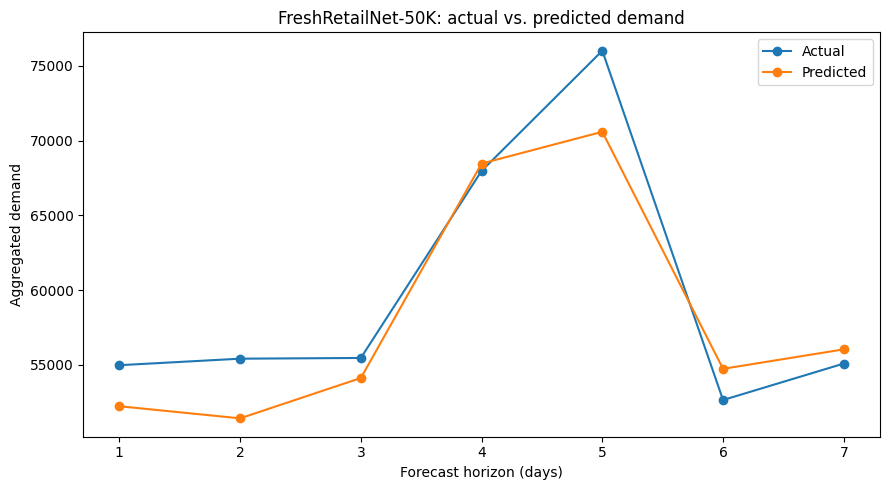

In [ ]:

import matplotlib.pyplot as plt

plot_data = (
    final_predictions.groupby("horizon", observed=True)[["target", "prediction"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(plot_data["horizon"], plot_data["target"], marker="o", label="Actual")
plt.plot(plot_data["horizon"], plot_data["prediction"], marker="o", label="Predicted")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("Aggregated demand")
plt.title("FreshRetailNet-50K: actual vs. predicted demand")
plt.legend()
plt.tight_layout()
plt.show()


## 19. Optional SHAP interpretation

SHAP is computed only on a small evaluation sample. The full tuning and feature-selection workflow does not depend on SHAP.


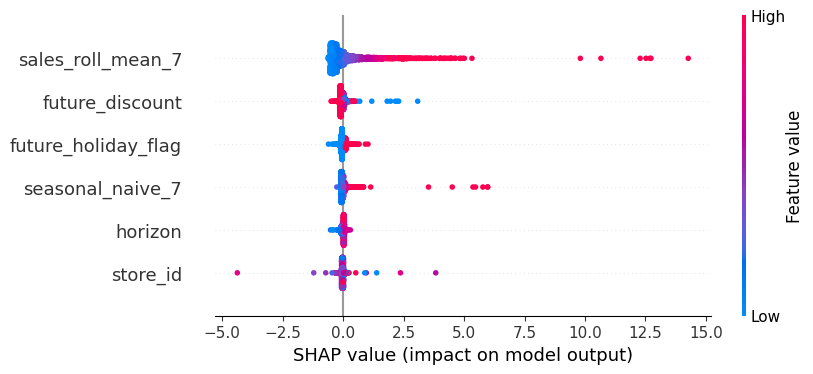

In [ ]:

import shap

shap_sample = final_evaluation_data.sample(
    n=min(2_000, len(final_evaluation_data)),
    random_state=config.random_seed,
)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(shap_sample[combined_result.selected_features])

shap.plots.beeswarm(shap_values, max_display=25)


## 20. Save final artifacts

In [ ]:

save_final_artifacts(
    model=final_model,
    predictions=final_predictions,
    metrics=final_metrics,
    result=combined_result,
    config=config,
)

print("Artifacts saved to:", Path(config.output_dir).resolve())
for path in sorted(Path(config.output_dir).rglob("*")):
    if path.is_file():
        print("-", path)


Artifacts saved to: /content/artifacts/freshretail_full_gpu_uploaded_code_method
- artifacts/freshretail_full_gpu_uploaded_code_method/checkpoints/feature_selection_chunk_log.csv
- artifacts/freshretail_full_gpu_uploaded_code_method/checkpoints/feature_selection_log.csv
- artifacts/freshretail_full_gpu_uploaded_code_method/checkpoints/selected_features.json
- artifacts/freshretail_full_gpu_uploaded_code_method/chunk_and_cv_reset_log.csv
- artifacts/freshretail_full_gpu_uploaded_code_method/config.json
- artifacts/freshretail_full_gpu_uploaded_code_method/feature_selection_log.csv
- artifacts/freshretail_full_gpu_uploaded_code_method/final_metrics.csv
- artifacts/freshretail_full_gpu_uploaded_code_method/final_optuna_selected_features_with_l1_l2_best_params.json
- artifacts/freshretail_full_gpu_uploaded_code_method/final_optuna_selected_features_with_l1_l2_chunk_log.csv
- artifacts/freshretail_full_gpu_uploaded_code_method/final_optuna_selected_features_with_l1_l2_optuna_trials.csv
- ar

## 21. Compare the official evaluation result with FreshRetailNet-50K Table 3

The table compares this notebook's single final framework with published results for the same three sales groups.

A direct claim requires:

- all 50,000 store-product series;
- the untouched official seven-day evaluation period;
- evaluation only on non-stockout target days;
- the same Overall, Low Sale, and High Sale definitions;
- WAPE and WPE calculated using the same sign convention.


In [ ]:

# Published forecasting results from FreshRetailNet-50K Table 3.
published_results = pd.DataFrame([
    # Overall
    {"sales_group": "Overall", "source": "Paper", "model": "SSA", "recovery": "Raw Sales", "wape": 0.3197, "wpe": -0.1050},
    {"sales_group": "Overall", "source": "Paper", "model": "TFT", "recovery": "Raw Sales", "wape": 0.3175, "wpe": -0.0737},
    {"sales_group": "Overall", "source": "Paper", "model": "DLinear", "recovery": "Raw Sales", "wape": 0.3156, "wpe": -0.0489},
    {"sales_group": "Overall", "source": "Paper", "model": "TFT", "recovery": "TimesNet", "wape": 0.2902, "wpe": 0.0258},

    # Low-sale group
    {"sales_group": "Low Sale", "source": "Paper", "model": "SSA", "recovery": "Raw Sales", "wape": 0.3833, "wpe": -0.0803},
    {"sales_group": "Low Sale", "source": "Paper", "model": "TFT", "recovery": "Raw Sales", "wape": 0.3704, "wpe": -0.0172},
    {"sales_group": "Low Sale", "source": "Paper", "model": "DLinear", "recovery": "Raw Sales", "wape": 0.3978, "wpe": -0.0103},
    {"sales_group": "Low Sale", "source": "Paper", "model": "TFT", "recovery": "TimesNet", "wape": 0.3733, "wpe": 0.0778},

    # High-sale group
    {"sales_group": "High Sale", "source": "Paper", "model": "SSA", "recovery": "Raw Sales", "wape": 0.2740, "wpe": -0.1226},
    {"sales_group": "High Sale", "source": "Paper", "model": "TFT", "recovery": "Raw Sales", "wape": 0.2795, "wpe": -0.1146},
    {"sales_group": "High Sale", "source": "Paper", "model": "DLinear", "recovery": "Raw Sales", "wape": 0.2568, "wpe": -0.0763},
    {"sales_group": "High Sale", "source": "Paper", "model": "TFT", "recovery": "TimesNet", "wape": 0.2303, "wpe": 0.0087},
])

our_rows = final_metrics[
    (final_metrics["subset"] == "uncensored_target_days")
    & (final_metrics["horizon"].astype(str) == "overall")
].copy()

expected_groups = {"Overall", "Low Sale", "High Sale"}
actual_groups = set(our_rows["sales_group"])
if actual_groups != expected_groups:
    raise RuntimeError(
        f"Expected paper groups {expected_groups}, found {actual_groups}"
    )

our_results = our_rows.rename(
    columns={"wape": "wape", "wpe": "wpe"}
)[["sales_group", "wape", "wpe"]].copy()
our_results["source"] = "This notebook"
our_results["model"] = "GPU XGBoost"
our_results["recovery"] = "Raw Sales"
our_results["framework"] = (
    "Initial Optuna + fixed-HP individual GridSearchCV FFS with "
    "chunk/CV reset + final Optuna including L1/L2"
)

published_results["framework"] = "Published protocol"
benchmark = pd.concat(
    [published_results, our_results],
    ignore_index=True,
    sort=False,
)
benchmark["WAPE (%)"] = 100 * benchmark["wape"]
benchmark["WPE (%)"] = 100 * benchmark["wpe"]

our_wape_by_group = our_results.set_index("sales_group")["wape"]
benchmark["difference_vs_our_WAPE_pp"] = benchmark.apply(
    lambda row: 100 * (
        row["wape"] - our_wape_by_group.loc[row["sales_group"]]
    ),
    axis=1,
)

benchmark = benchmark.sort_values(
    ["sales_group", "wape"],
    ascending=[True, True],
).reset_index(drop=True)

display(
    benchmark[
        [
            "sales_group",
            "source",
            "model",
            "recovery",
            "framework",
            "WAPE (%)",
            "WPE (%)",
            "difference_vs_our_WAPE_pp",
        ]
    ]
)

summary_rows = []
for sales_group in ["Overall", "Low Sale", "High Sale"]:
    ours = our_results[our_results["sales_group"] == sales_group].iloc[0]
    paper_group = published_results[
        published_results["sales_group"] == sales_group
    ]
    best_raw = paper_group[
        paper_group["recovery"] == "Raw Sales"
    ].sort_values("wape").iloc[0]
    best_published = paper_group.sort_values("wape").iloc[0]

    summary_rows.append({
        "sales_group": sales_group,
        "our_WAPE_percent": 100 * ours["wape"],
        "our_WPE_percent": 100 * ours["wpe"],
        "difference_vs_best_raw_sales_paper_pp": 100 * (
            ours["wape"] - best_raw["wape"]
        ),
        "difference_vs_best_published_paper_pp": 100 * (
            ours["wape"] - best_published["wape"]
        ),
    })

comparison_summary = pd.DataFrame(summary_rows)
display(comparison_summary)

run_metadata = {
    "full_dataset_used": config.series_limit is None,
    "official_horizon_days": config.forecast_horizon,
    "evaluation_like_cv_chunk_days": config.cv_chunk_days,
    "feature_selection_acceptance_rule": (
        config.feature_selection_acceptance_rule
    ),
    "gpu_device": config.xgb_device,
    "final_reg_alpha_l1": combined_result.final_params.get("reg_alpha"),
    "final_reg_lambda_l2": combined_result.final_params.get("reg_lambda"),
}
print(json.dumps(run_metadata, indent=2, default=_json_default))


,sales_group,source,model,recovery,framework,WAPE (%),WPE (%),difference_vs_our_WAPE_pp
0,High Sale,Paper,TFT,TimesNet,Published protocol,23.030000,0.870000,-5.710679
1,High Sale,Paper,DLinear,Raw Sales,Published protocol,25.680000,-7.630000,-3.060679
2,High Sale,Paper,SSA,Raw Sales,Published protocol,27.400000,-12.260000,-1.340679
3,High Sale,Paper,TFT,Raw Sales,Published protocol,27.950000,-11.460000,-0.790679
4,High Sale,This notebook,GPU XGBoost,Raw Sales,Initial Optuna + fixed-HP individual GridSearc...,28.740679,-11.122281,0.000000
5,Low Sale,Paper,TFT,Raw Sales,Published protocol,37.040000,-1.720000,-1.897684
6,Low Sale,Paper,TFT,TimesNet,Published protocol,37.330000,7.780000,-1.607684
7,Low Sale,Paper,SSA,Raw Sales,Published protocol,38.330000,-8.030000,-0.607684
8,Low Sale,This notebook,GPU XGBoost,Raw Sales,Initial Optuna + fixed-HP individual GridSearc...,38.937684,3.114717,0.000000
9,Low Sale,Paper,DLinear,Raw Sales,Published protocol,39.780000,-1.030000,0.842316


,sales_group,our_WAPE_percent,our_WPE_percent,difference_vs_best_raw_sales_paper_pp,difference_vs_best_published_paper_pp
0,Overall,33.030551,-5.132787,1.470551,4.010551
1,Low Sale,38.937684,3.114717,1.897684,1.897684
2,High Sale,28.740679,-11.122281,3.060679,5.710679


{
  "full_dataset_used": true,
  "official_horizon_days": 7,
  "evaluation_like_cv_chunk_days": 7,
  "feature_selection_acceptance_rule": "uploaded_notebook",
  "gpu_device": "cuda",
  "final_reg_alpha_l1": 1.2281691079272938,
  "final_reg_lambda_l2": 160.79648396006553
}


## Final methodological statement for the README or report

> We followed the model-development sequence used in the uploaded LUR notebook. First, XGBoost learning rate, number of estimators, maximum tree depth, and subsampling were optimized with Optuna on evaluation-like temporal cross-validation chunks. These hyperparameters were then frozen. Forward feature selection was performed one variable at a time with `GridSearchCV`, using a singleton parameter grid and mean negative MSE. After each accepted variable, the seven-day validation chunks and CV folds were regenerated. Selection stopped when the best remaining variable no longer improved the accepted negative-MSE score. Finally, all selected variables were used in a second Optuna study that jointly optimized the original hyperparameters together with L1 (`reg_alpha`) and L2 (`reg_lambda`). The final GPU XGBoost model was trained on the complete development period and evaluated once on the untouched official seven-day evaluation period.
